In [1]:
# Install required packages
#!pip install --break-system-packages pandas numpy matplotlib seaborn scikit-learn scipy networkx python-louvain transformers torch sentence-transformers bert-score tqdm -q

In [2]:
#!pip install --upgrade pip setuptools wheel -q
#!pip uninstall -y transformers sentence-transformers
#!pip install transformers sentence-transformers -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import euclidean
from scipy.stats import entropy
import community.community_louvain as community_louvain
from sentence_transformers import SentenceTransformer, CrossEncoder
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm.auto import tqdm
import warnings
import re
import string
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import skew, kurtosis
from sklearn.feature_extraction.text import TfidfVectorizer
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")

/home/mhadi/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully!


In [3]:
direc = '/home/mhadi/Notebooks/sim3/'
plot_direc = direc+"plots/"

## Step 1: Data Collection

In [4]:
ref_df = pd.read_csv(direc+ 'topic_tweets.csv')
ref_df.head()

,id,tweet,post_img,user_id,comment_to,thread_id,round,news_id,shared_from,image_id,reaction_count,day,hour,like,dislike,post_id,topic_id,topic,length
0,1,"I'm tellin' ya, AI's gonna change everything! ...",0,56,-1,1,1,0,-1,0,15,0,0,11.0,4.0,1,2,AI causing mass unemployment,192
1,2,"I'm tellin' ya, AI's gonna change everything! ...",0,56,-1,2,1,0,-1,0,16,0,0,13.0,3.0,2,2,AI causing mass unemployment,192
2,3,"@EricThompson You're so caught up in the hype,...",0,52,2,2,2,0,-1,0,10,0,1,10.0,0.0,3,2,AI causing mass unemployment,255
3,4,@BrandonColeman I completely agree with you! I...,0,20,2,2,2,0,-1,0,13,0,1,13.0,0.0,4,2,AI causing mass unemployment,363
4,5,I'm so excited to see AI bringing an economic ...,0,19,-1,5,2,0,-1,0,10,0,1,7.0,3.0,5,4,AI bringing an economic boom,191


In [5]:
#topic_ids = ref_df.loc[ref_df['topic'] == 'sports', 'id']

In [6]:
# Load the dataset
df = pd.read_csv(direc+ 'sentiment_results.csv')

# keeping tweets only on Climate change topic!
#df = df[df['id'].isin(topic_ids)]

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (538, 41)

Columns: ['id', 'tweet', 'post_img', 'user_id', 'comment_to', 'thread_id', 'round', 'news_id', 'shared_from', 'image_id', 'reaction_count', 'day', 'hour', 'like', 'dislike', 'length', 'true_topics', 'clean_text', 'is_empty', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound', 'vader_label', 'roberta_neg', 'roberta_neu', 'roberta_pos', 'roberta_label', 'roberta_score', 'roberta_compound', 'emotion_anger', 'emotion_disgust', 'emotion_fear', 'emotion_joy', 'emotion_neutral', 'emotion_sadness', 'emotion_surprise', 'emotion_label', 'emotion_score', 'emotion_valence', 'emotion_arousal']

First few rows:


,id,tweet,post_img,user_id,comment_to,thread_id,round,news_id,shared_from,image_id,...,emotion_disgust,emotion_fear,emotion_joy,emotion_neutral,emotion_sadness,emotion_surprise,emotion_label,emotion_score,emotion_valence,emotion_arousal
0,1,"I'm tellin' ya, AI's gonna change everything! ...",0,56,-1,1,1,0,-1,0,...,0.002971,0.012928,0.088246,0.221041,0.102164,0.483108,surprise,0.483108,0.036345,0.059731
1,2,"I'm tellin' ya, AI's gonna change everything! ...",0,56,-1,2,1,0,-1,0,...,0.002971,0.012928,0.088246,0.221041,0.102164,0.483108,surprise,0.483108,0.036345,0.059731
2,3,"@EricThompson You're so caught up in the hype,...",0,52,2,2,2,0,-1,0,...,0.004348,0.013820,0.036268,0.689751,0.113538,0.039325,neutral,0.689751,-0.022397,-0.221121
3,4,@BrandonColeman I completely agree with you! I...,0,20,2,2,2,0,-1,0,...,0.001218,0.007754,0.767022,0.041624,0.017779,0.033991,joy,0.767022,0.727682,0.214638
4,5,I'm so excited to see AI bringing an economic ...,0,19,-1,5,2,0,-1,0,...,0.000222,0.000488,0.985613,0.001047,0.005347,0.005837,joy,0.985613,0.983738,0.246140


In [7]:
# Basic data exploration
print("Dataset Info:")
print(f"Total tweets: {len(df)}")
print(f"Unique users: {df['user_id'].nunique()}")
print(f"Date range: Day {df['day'].min()} to Day {df['day'].max()}")
print(f"\nMissing values:")
print(df.isnull().sum())# Basic data exploration
print("Dataset Info:")
print(f"Total tweets: {len(df)}")
print(f"Unique users: {df['user_id'].nunique()}")
print(f"Date range: Day {df['day'].min()} to Day {df['day'].max()}")
print(f"\nMissing values:")
print(df.isnull().sum())

Dataset Info:
Total tweets: 538
Unique users: 93
Date range: Day 0 to Day 6

Missing values:
id                  0
tweet               0
post_img            0
user_id             0
comment_to          0
thread_id           0
round               0
news_id             0
shared_from         0
image_id            0
reaction_count      0
day                 0
hour                0
like                0
dislike             0
length              0
true_topics         0
clean_text          0
is_empty            0
vader_neg           0
vader_neu           0
vader_pos           0
vader_compound      0
vader_label         0
roberta_neg         0
roberta_neu         0
roberta_pos         0
roberta_label       0
roberta_score       0
roberta_compound    0
emotion_anger       0
emotion_disgust     0
emotion_fear        0
emotion_joy         0
emotion_neutral     0
emotion_sadness     0
emotion_surprise    0
emotion_label       0
emotion_score       0
emotion_valence     0
emotion_arousal     0
dtype

## Step 2: Text Preprocessing

In [8]:
def preprocess_text(text):
    """Clean and normalize text"""
    if pd.isna(text) or text == '':
        return ""

    # Convert to lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove mentions and hashtags (keep the text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply preprocessing
df['processed_text'] = df['clean_text'].apply(preprocess_text)

# Filter out very short texts (less than 10 characters)
df = df[df['processed_text'].str.len() >= 10].copy()

print(f"After preprocessing: {len(df)} tweets remaining")
print(f"\nSample processed text:")
print(df['processed_text'])

After preprocessing: 538 tweets remaining

Sample processed text:
0      i'm tellin' ya, ai's gonna change everything! ...
1      i'm tellin' ya, ai's gonna change everything! ...
2      you're so caught up in the hype, you're forget...
3      i completely agree with you! it's easy to get ...
4      i'm so excited to see ai bringing an economic ...
                             ...                        
533    can't believe the complacency! ai is not the s...
534    ai's potential to cure diseases is limitless! ...
535    the threat of ai takeover is real! we can't ju...
536    i'm glad someone like you, , is finally speaki...
537    wake up, folks! ai's gonna wipe out most jobs ...
Name: processed_text, Length: 538, dtype: str


## Step 3: Text Embedding Extraction

In [9]:
# Load sentence transformer model
print("Loading Sentence-BERT model...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings for all texts
print("Generating embeddings...")
texts = df['clean_text'].tolist()
embeddings = embedding_model.encode(texts, show_progress_bar=True, batch_size=32)

print(f"\nEmbedding shape: {embeddings.shape}")
print(f"Embedding dimension: {embeddings.shape[1]}")

Loading Sentence-BERT model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5307.16it/s]


Generating embeddings...


Batches: 100%|██████████| 17/17 [00:03<00:00,  5.38it/s]


Embedding shape: (538, 384)
Embedding dimension: 384


## Step 4: Prototype Stance Construction

We'll use the sentiment scores from the dataset to identify pro and anti stances.

In [10]:
# Use vader_compound or roberta_compound as initial stance indicator
df['stance_score_initial'] = df['roberta_compound']

# Define pro and anti based on compound sentiment
# Pro: positive sentiment (compound > 0.3)
# Anti: negative sentiment (compound < -0.3)
# Neutral: between -0.3 and 0.3

pro_mask = df['stance_score_initial'] > 0.3
anti_mask = df['stance_score_initial'] < -0.3

pro_embeddings = embeddings[pro_mask]
anti_embeddings = embeddings[anti_mask]

# Calculate prototype embeddings (mean of each group)
prototype_pro = np.mean(pro_embeddings, axis=0) if len(pro_embeddings) > 0 else np.zeros(embeddings.shape[1])
prototype_anti = np.mean(anti_embeddings, axis=0) if len(anti_embeddings) > 0 else np.zeros(embeddings.shape[1])

print(f"Pro-stance tweets: {sum(pro_mask)}")
print(f"Anti-stance tweets: {sum(anti_mask)}")
print(f"Neutral tweets: {len(df) - sum(pro_mask) - sum(anti_mask)}")

Pro-stance tweets: 162
Anti-stance tweets: 293
Neutral tweets: 83


## Step 5: Stance Estimation

### 5.1 Embedding-Based Similarity

In [11]:
# Calculate cosine similarity with prototypes
def calculate_stance_similarity(embedding, proto_pro, proto_anti):
    """Calculate stance based on similarity to prototypes"""
    sim_pro = cosine_similarity([embedding], [proto_pro])[0][0]
    sim_anti = cosine_similarity([embedding], [proto_anti])[0][0]

    # Stance score: difference between similarities
    stance_score = sim_pro - sim_anti
    return stance_score, sim_pro, sim_anti

# Calculate for all embeddings
stance_results = [calculate_stance_similarity(emb, prototype_pro, prototype_anti)
                  for emb in tqdm(embeddings, desc="Calculating stance similarity")]

df['stance_similarity'] = [s[0] for s in stance_results]
df['sim_pro'] = [s[1] for s in stance_results]
df['sim_anti'] = [s[2] for s in stance_results]

print("Stance similarity calculated!")
print(f"Mean stance similarity: {df['stance_similarity'].mean():.4f}")
print(f"Std stance similarity: {df['stance_similarity'].std():.4f}")

Calculating stance similarity: 100%|██████████| 538/538 [00:00<00:00, 1801.01it/s]


Stance similarity calculated!
Mean stance similarity: -0.0077
Std stance similarity: 0.0384


#### 5.2 Cross-Encoder Similarity

In [12]:
# Multi-anchor stance description texts
pro_anchors = [
    "Artificial intelligence will revolutionize healthcare by accelerating drug discovery, curing complex diseases, and ultimately saving countless lives.",
    "The widespread adoption of AI will trigger an unprecedented economic boom, supercharging global productivity and creating entirely new industries.",
    "AI is humanity's most powerful tool for solving intractable global challenges, from managing the climate crisis to ending resource scarcity."
]

anti_anchors = [
    "The rapid deployment of automation and AI will inevitably cause mass global unemployment, rendering millions of human workers obsolete.",
    "Unchecked advancement toward artificial general intelligence (AGI) represents a literal existential threat that could lead to human extinction.",
    "Delegating critical decisions to opaque AI algorithms will result in a dystopian nightmare of surveillance, automated bias, and loss of human agency."
]

# Calculate cross-encoder scores for all texts
# In production, you might want to run this on the full dataset

print(f"Loading cross-encoder for {len(df)} texts...")
cross_encoder = CrossEncoder('cross-encoder/stsb-roberta-base')

# Calculate cross-encoder scores using multi-anchor approach
cross_encoder_scores = []
for idx in tqdm(df.index, desc="Cross-encoder scoring"):
    text = df.loc[idx, 'clean_text']

    # Calculate scores against all pro anchors
    pro_comparison_pairs = [(text, anchor) for anchor in pro_anchors]
    scores_pro_anchors = cross_encoder.predict(pro_comparison_pairs)
    score_pro_aggregated = np.mean(scores_pro_anchors)

    # Calculate scores against all anti anchors
    anti_comparison_pairs = [(text, anchor) for anchor in anti_anchors]
    scores_anti_anchors = cross_encoder.predict(anti_comparison_pairs)
    score_anti_aggregated = np.mean(scores_anti_anchors)

    cross_encoder_scores.append(score_pro_aggregated - score_anti_aggregated)

# Store results
df['cross_encoder_score'] = cross_encoder_scores

print("Cross-encoder scoring completed with Multi-Anchor Approach!")

Loading cross-encoder for 538 texts...


Cross-encoder scoring: 100%|██████████| 538/538 [02:45<00:00,  3.25it/s]

Cross-encoder scoring completed with Multi-Anchor Approach!


## Step 6: Ensemble Stance Fusion

In [13]:

scaler = MinMaxScaler(feature_range=(-1, 1))

# Normalize stance similarity
df['stance_similarity_norm'] = scaler.fit_transform(df[['stance_similarity']])

# Normalize cross-encoder scores (only for available values)
df['cross_encoder_norm'] = df['cross_encoder_score']
non_null_mask = df['cross_encoder_norm'].notna()
if non_null_mask.sum() > 0:
    df.loc[non_null_mask, 'cross_encoder_norm'] = scaler.fit_transform(
        df.loc[non_null_mask, ['cross_encoder_score']]
    )

# Ensemble fusion with weights
# Weight: 0.6 for embedding similarity, 0.4 for cross-encoder (when available)
df['stance_ensemble'] = df['stance_similarity_norm'].copy()

# Add cross-encoder where available
ce_available = df['cross_encoder_norm'].notna()
df.loc[ce_available, 'stance_ensemble'] = (
    0.6 * df.loc[ce_available, 'stance_similarity_norm'] +
    0.4 * df.loc[ce_available, 'cross_encoder_norm']
)

print("Ensemble stance fusion completed!")
print(f"\nStance distribution:")
print(f"Mean: {df['stance_ensemble'].mean():.4f}")
print(f"Std: {df['stance_ensemble'].std():.4f}")
print(f"Min: {df['stance_ensemble'].min():.4f}")
print(f"Max: {df['stance_ensemble'].max():.4f}")

Ensemble stance fusion completed!

Stance distribution:
Mean: -0.0973
Std: 0.3742
Min: -0.7696
Max: 1.0000


## Step 7: Sentiment Analysis

We already have sentiment scores from the dataset (VADER and RoBERTa)

Sentiment statistics:
count    538.000000
mean      -0.207454
std        0.685351
min       -0.949845
25%       -0.853465
50%       -0.467842
75%        0.435656
max        0.982979
Name: sentiment_score, dtype: float64


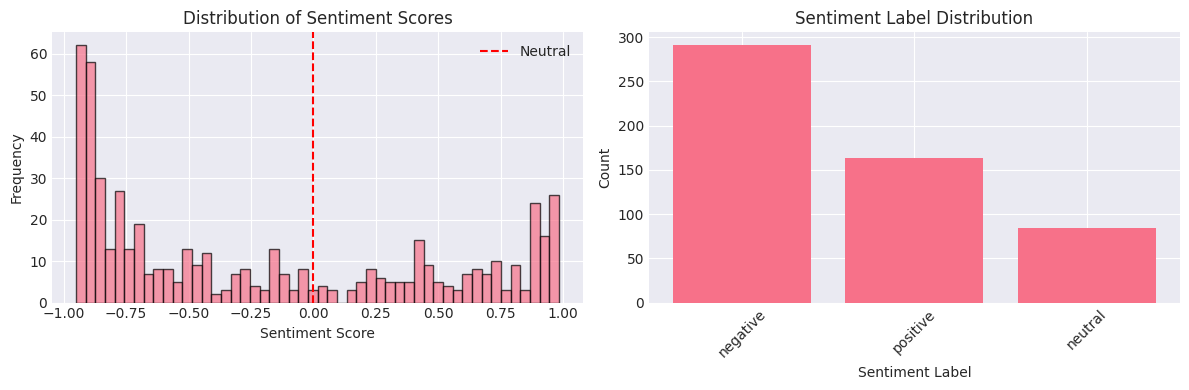

In [14]:
# Use RoBERTa compound sentiment as our primary sentiment measure
df['sentiment_score'] = df['roberta_compound']

print("Sentiment statistics:")
print(df['sentiment_score'].describe())

# Visualize sentiment distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['sentiment_score'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.title('Distribution of Sentiment Scores')
plt.axvline(x=0, color='r', linestyle='--', label='Neutral')
plt.legend()

plt.subplot(1, 2, 2)
sentiment_labels = df['roberta_label'].value_counts()
plt.bar(sentiment_labels.index, sentiment_labels.values)
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.title('Sentiment Label Distribution')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(plot_direc + 'sentiment_distribution.png')
plt.show()

## Step 8: Attitude Score Construction

Attitude scores calculated!

Attitude statistics:
count    538.000000
mean      -0.121117
std        0.427910
min       -0.803501
25%       -0.457458
50%       -0.162556
75%        0.158609
max        0.903272
Name: attitude_score, dtype: float64


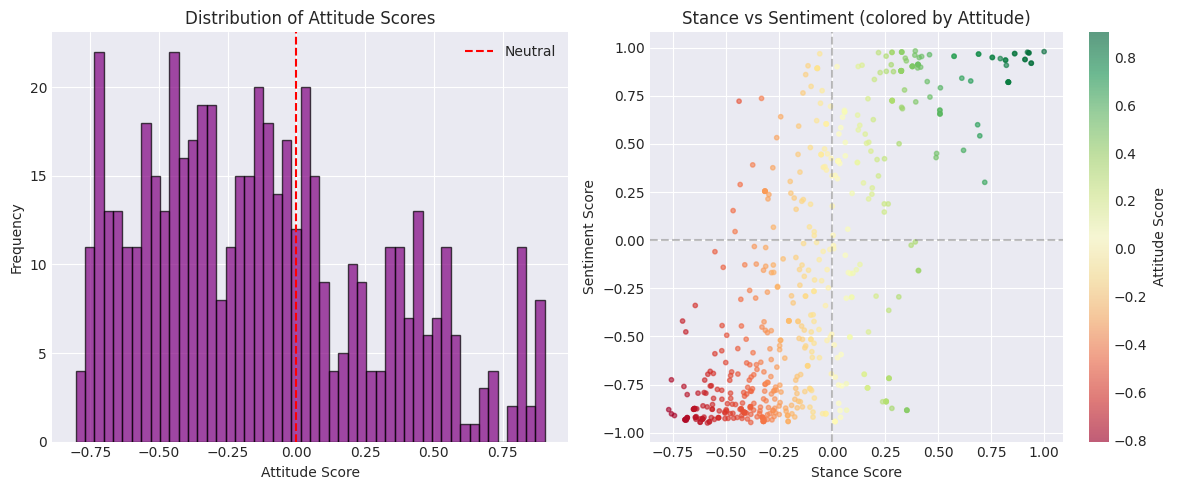

In [15]:
# Combine stance and sentiment to create attitude score
# Attitude = Stance (direction) * Sentiment (intensity)
# This creates a score where:
# - Positive stance + positive sentiment = strong positive attitude
# - Positive stance + negative sentiment = weak/conflicted attitude
# - Negative stance + negative sentiment = strong negative attitude
beta = 0.5
def calculate_attitude_score(stance, sentiment):
    """Calculate attitude score from stance and sentiment"""
    # Normalize sentiment to [-1, 1] if needed
    # Attitude combines directional stance with emotional intensity
    #attitude = stance * (1 + abs(sentiment)) / 2

    ### =============== version 1: sentiment just amplify the attitude in the direction of original stance ===================
    amplifier = 1 + (beta * abs(sentiment))
    attitude = np.tanh(stance * amplifier)


    ### ============== version 2: sentiment can weaken or strengthen ========================
    #attitude = stance * (1+beta *sentiment)

    return np.clip(attitude, -1, 1)

df['attitude_score'] = df.apply(
    lambda row: calculate_attitude_score(row['stance_ensemble'], row['sentiment_score']),
    axis=1
)

print("Attitude scores calculated!")
print(f"\nAttitude statistics:")
print(df['attitude_score'].describe())

# Visualize attitude scores
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['attitude_score'], bins=50, edgecolor='black', alpha=0.7, color='purple')
plt.xlabel('Attitude Score')
plt.ylabel('Frequency')
plt.title('Distribution of Attitude Scores')
plt.axvline(x=0, color='r', linestyle='--', label='Neutral')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(df['stance_ensemble'], df['sentiment_score'],
            c=df['attitude_score'], cmap='RdYlGn', alpha=0.6, s=10)
plt.xlabel('Stance Score')
plt.ylabel('Sentiment Score')
plt.title('Stance vs Sentiment (colored by Attitude)')
plt.colorbar(label='Attitude Score')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(plot_direc + 'attitude_scores_distribution_vs_stance_sentiment.png')
plt.show()

## Step 9: User-Level Attitude Aggregation


User-level attitudes calculated for 93 users

User attitude statistics:
       mean_attitude  weighted_attitude  attitude_std
count      93.000000          93.000000     76.000000
mean       -0.103274          -0.100552      0.236166
std         0.369409           0.398354      0.150989
min        -0.746957          -0.753761      0.000000
25%        -0.380697          -0.380697      0.133680
50%        -0.137410          -0.142860      0.226754
75%         0.068297           0.128571      0.332283
max         0.903272           0.903272      0.632811


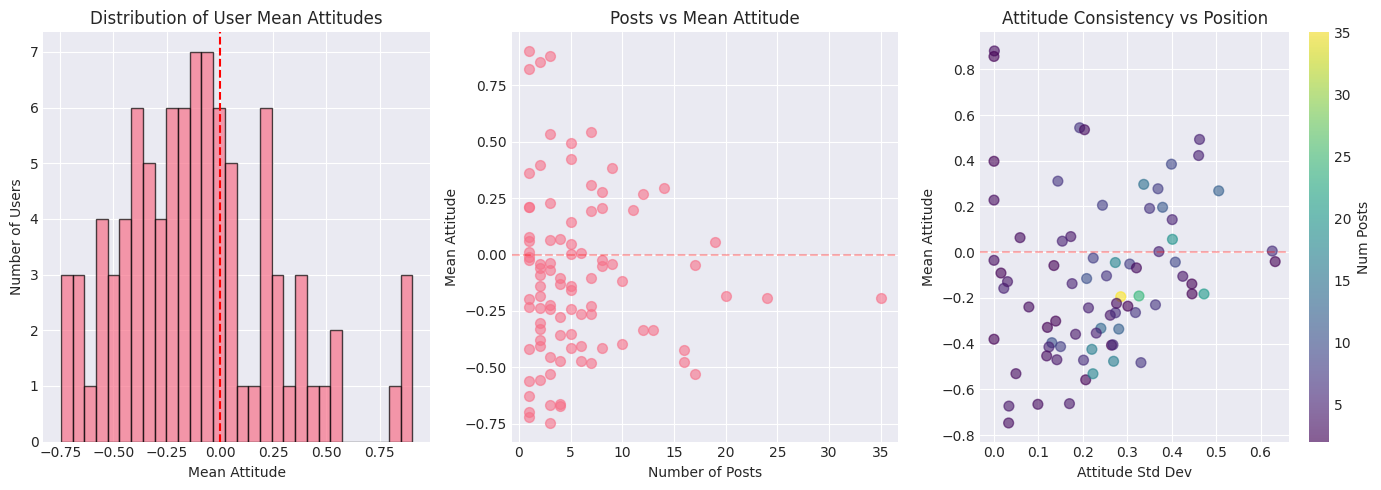

In [16]:
# Aggregate attitudes at user level
# We'll use multiple aggregation strategies

def aggregate_user_attitudes(user_df):
    """Aggregate attitudes for a single user"""
    attitudes = user_df['attitude_score'].values
    days = user_df['day'].values

    # Mean aggregation
    mean_attitude = np.mean(attitudes)

    # Recency-weighted (more recent posts weighted more)
    weights = np.exp(days - days.max())  # Exponential decay
    weighted_attitude = np.average(attitudes, weights=weights)

    # Engagement-weighted (if like/reaction counts available)
    engagement = user_df['like'].values + 1  # Add 1 to avoid zero weights
    engagement_weighted = np.average(attitudes, weights=engagement)

    return pd.Series({
        'mean_attitude': mean_attitude,
        'weighted_attitude': weighted_attitude,
        'engagement_weighted_attitude': engagement_weighted,
        'attitude_std': np.std(attitudes),
        'num_posts': len(attitudes),
        'total_likes': user_df['like'].sum(),
        'total_reactions': user_df['reaction_count'].sum()
    })

# Aggregate by user
user_attitudes = df.groupby('user_id').apply(aggregate_user_attitudes).reset_index()

user_attitudes.loc[user_attitudes['num_posts'] < 2, 'attitude_std'] = np.nan

print(f"\nUser-level attitudes calculated for {len(user_attitudes)} users")
print(f"\nUser attitude statistics:")
print(user_attitudes[['mean_attitude', 'weighted_attitude', 'attitude_std']].describe())

# Visualize user attitudes
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.hist(user_attitudes['mean_attitude'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Mean Attitude')
plt.ylabel('Number of Users')
plt.title('Distribution of User Mean Attitudes')
plt.axvline(x=0, color='r', linestyle='--')

plt.subplot(1, 3, 2)
plt.scatter(user_attitudes['num_posts'], user_attitudes['mean_attitude'],
            alpha=0.6, s=50)
plt.xlabel('Number of Posts')
plt.ylabel('Mean Attitude')
plt.title('Posts vs Mean Attitude')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(user_attitudes['attitude_std'], user_attitudes['mean_attitude'],
            alpha=0.6, s=50, c=user_attitudes['num_posts'], cmap='viridis')
plt.xlabel('Attitude Std Dev')
plt.ylabel('Mean Attitude')
plt.title('Attitude Consistency vs Position')
plt.colorbar(label='Num Posts')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(plot_direc + 'user_attitude_distribution.png')
plt.show()

In [17]:
user_attitudes

,user_id,mean_attitude,weighted_attitude,engagement_weighted_attitude,attitude_std,num_posts,total_likes,total_reactions
0,2,-0.746957,-0.726822,-0.737637,0.032952,3.0,2.0,7.0
1,3,-0.158030,-0.152664,-0.170474,0.022041,5.0,7.0,8.0
2,4,-0.699377,-0.699377,-0.699377,NaN,1.0,1.0,1.0
3,5,-0.665265,-0.632887,-0.682726,0.098775,3.0,5.0,5.0
4,6,-0.128731,-0.142860,-0.133798,0.030481,4.0,7.0,8.0
...,...,...,...,...,...,...,...,...
88,96,0.191561,0.501628,0.175218,0.350146,7.0,20.0,25.0
89,97,0.212340,0.212340,0.212340,NaN,1.0,1.0,1.0
90,98,-0.231139,-0.231139,-0.231139,NaN,1.0,9.0,9.0
91,99,0.310718,0.391606,0.338119,0.143781,7.0,10.0,10.0


## Step 10: Social Graph Construction

In [18]:
# Build social network graph from interactions
# Edges represent interactions (replies, retweets, mentions)

G = nx.DiGraph()  # Directed graph

# Add nodes (users) with attributes
for _, user in user_attitudes.iterrows():
    G.add_node(user['user_id'],
               attitude=user['mean_attitude'],
               num_posts=user['num_posts'],
               attitude_std=user['attitude_std'])

# Add edges based on interactions
# 1. Reply interactions
reply_interactions = df[df['comment_to'] != -1][['user_id', 'comment_to']].copy()

for _, row in reply_interactions.iterrows():
    source = row['user_id']
    # Find the user who posted the original tweet
    target_tweet = df[df['id'] == row['comment_to']]
    if len(target_tweet) > 0:
        target = target_tweet.iloc[0]['user_id']
        if source != target and source in G.nodes() and target in G.nodes():
            if G.has_edge(source, target):
                G[source][target]['weight'] += 1
            else:
                G.add_edge(source, target, weight=1, type='reply')

# 2. Retweet/Share interactions
retweet_interactions = df[df['shared_from'] != -1][['user_id', 'shared_from']].copy()

for _, row in retweet_interactions.iterrows():
    source = row['user_id']
    # Find original author
    target_tweet = df[df['id'] == row['shared_from']]
    if len(target_tweet) > 0:
        target = target_tweet.iloc[0]['user_id']
        if source != target and source in G.nodes() and target in G.nodes():
            if G.has_edge(source, target):
                G[source][target]['weight'] += 1
            else:
                G.add_edge(source, target, weight=1, type='retweet')

# Convert to undirected for community detection
G_undirected = G.to_undirected()

print(f"\nSocial Graph Statistics:")
print(f"Number of nodes (users): {G.number_of_nodes()}")
print(f"Number of edges (interactions): {G.number_of_edges()}")
print(f"Graph density: {nx.density(G):.4f}")
print(f"Number of connected components: {nx.number_weakly_connected_components(G)}")

if G.number_of_edges() > 0:
    print(f"Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")


Social Graph Statistics:
Number of nodes (users): 93
Number of edges (interactions): 228
Graph density: 0.0266
Number of connected components: 17
Average degree: 4.90


## Step 11: Attitude Propagation

Model social influence and opinion diffusion

Analyzing real progression over days: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


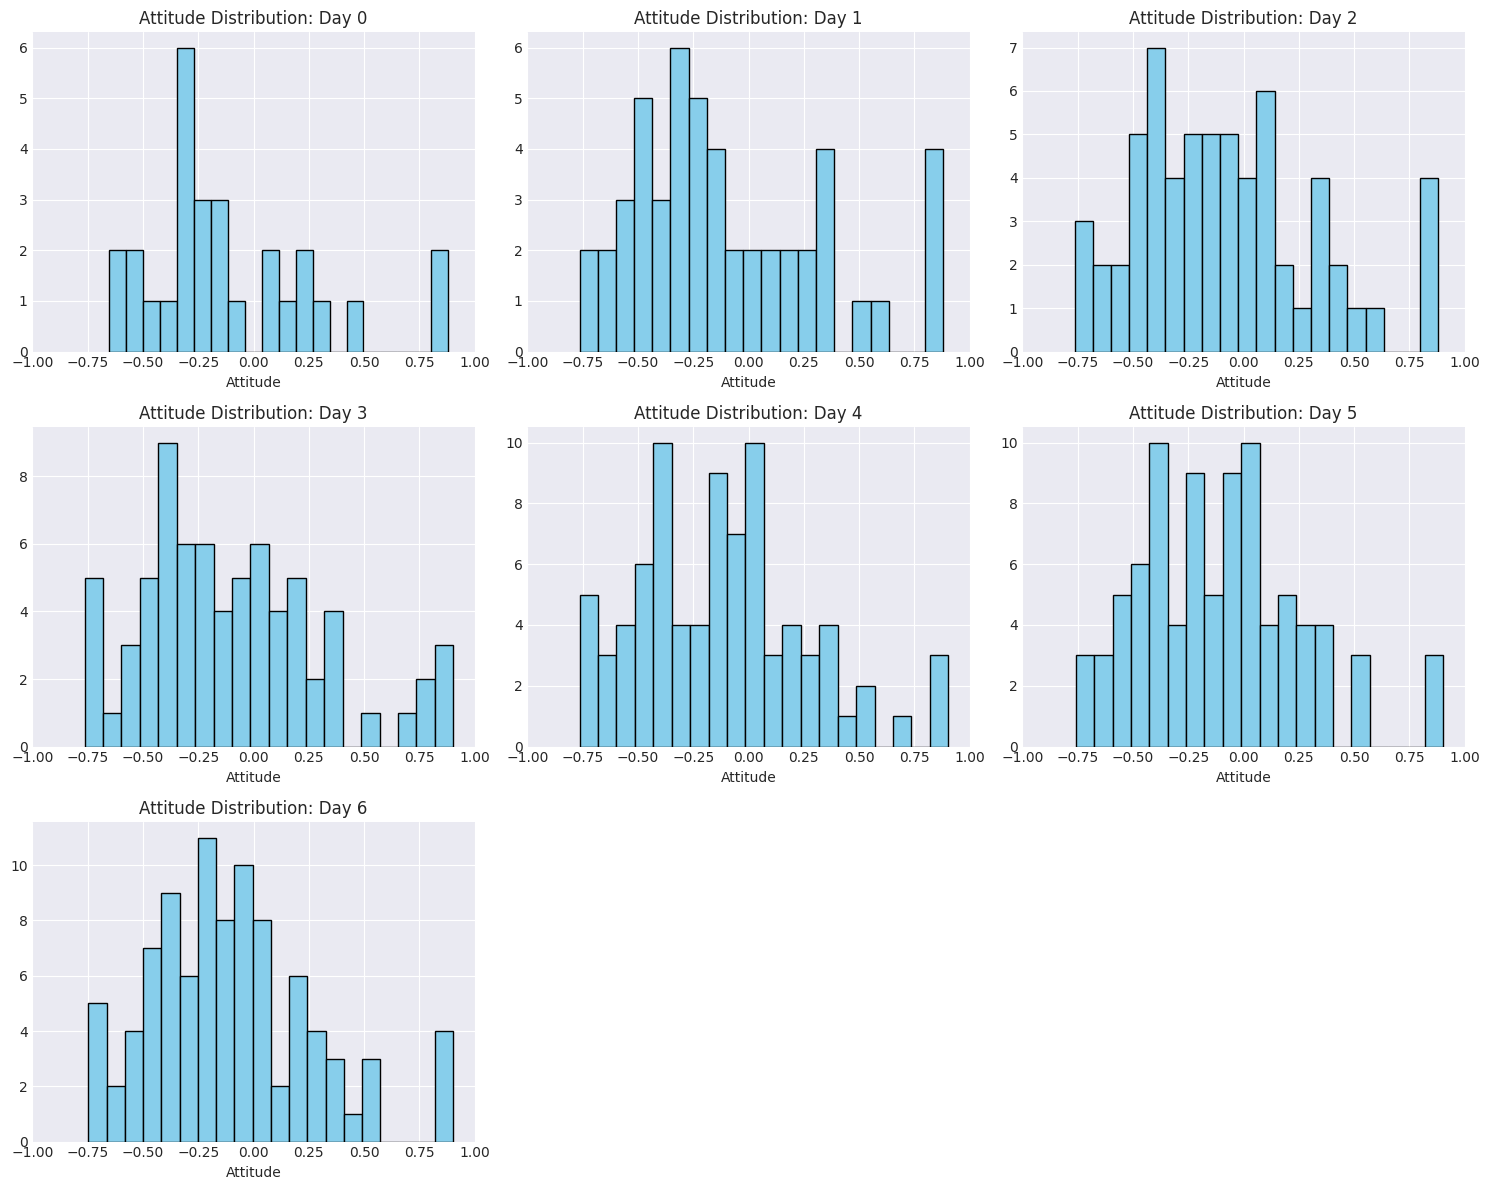

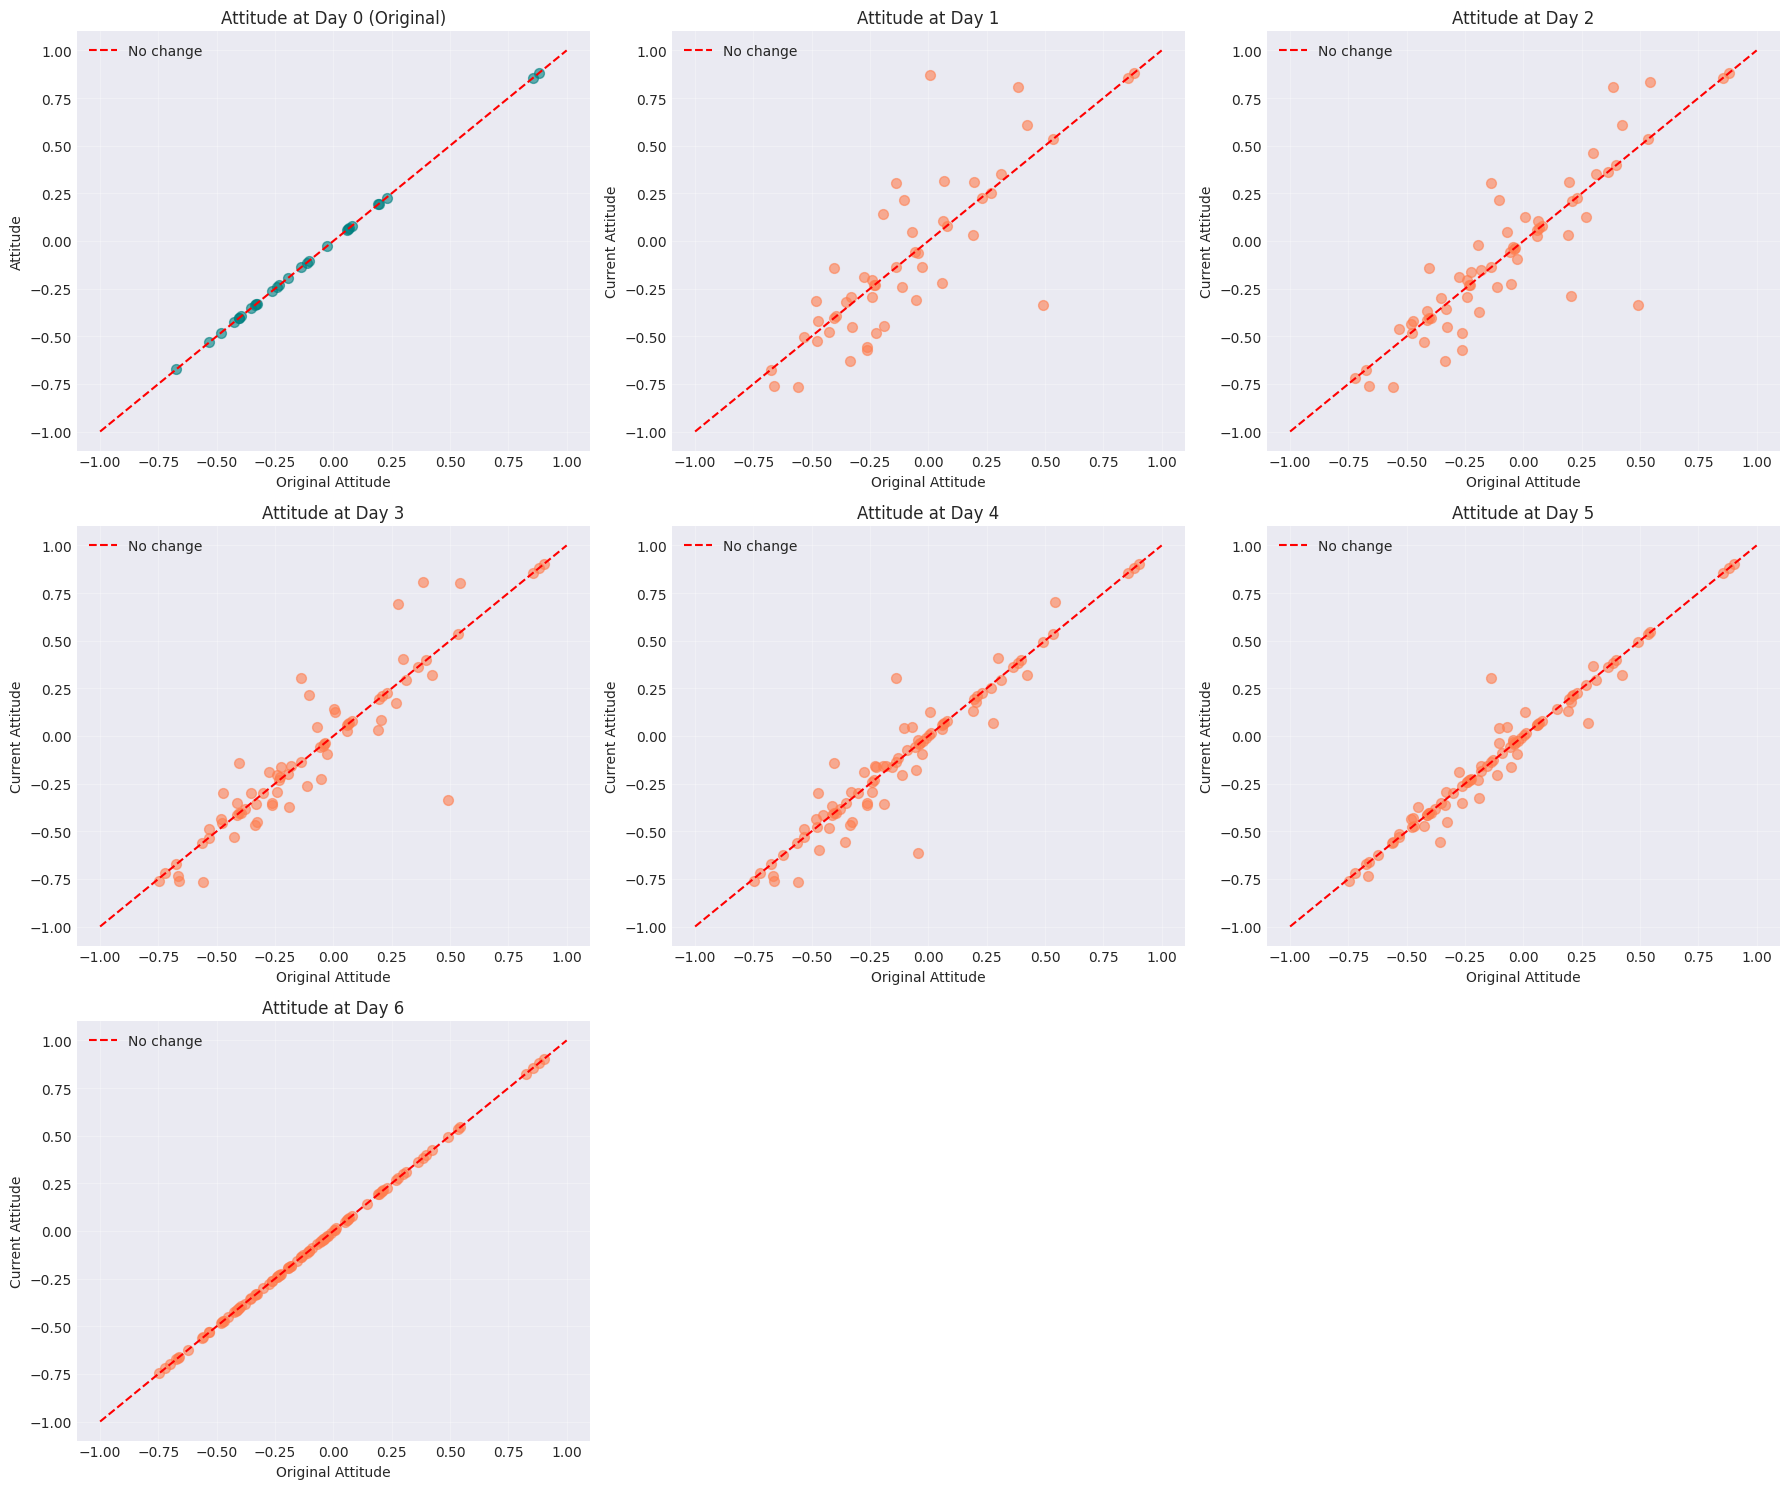


Real-world temporal analysis complete using 7 time steps.


In [19]:
def analyze_real_propagation(dataframe, attitudes_df):
    """
    Analyzes the actual change in attitudes over the days available in the dataset.
    Only considers users who have interacted up to or on the current day.
    """
    days = sorted(dataframe['day'].unique())
    real_propagation_history = {}

    print(f"Analyzing real progression over days: {days}")

    for day in days:
        day_df = dataframe[dataframe['day'] <= day]
        # Only consider users who have interacted up to or on this day
        day_attitudes = day_df.groupby('user_id')['attitude_score'].mean().to_dict()

        # Now, full_day_attitudes will only contain users who have an actual attitude score
        # This effectively removes users with a 0 attitude score from consideration for that day's distribution
        real_propagation_history[day] = day_attitudes

    return real_propagation_history

propagation_history = analyze_real_propagation(df, user_attitudes)

final_day = max(propagation_history.keys())
propagated_attitudes = propagation_history[final_day]
# Map only active users' propagated attitudes. Others will be NaN, which can be handled by .dropna()
user_attitudes['propagated_attitude'] = user_attitudes['user_id'].map(propagated_attitudes)

# --- Visualization Part 1: Histograms ---
num_snapshots = len(propagation_history)
cols = 3
rows = (num_snapshots + cols - 1) // cols

plt.figure(figsize=(cols * 5, rows * 4))
for i, day in enumerate(sorted(propagation_history.keys())):
    plt.subplot(rows, cols, i + 1)
    # Filter out empty days if no users were active, or NaN from map if not active
    day_scores = [score for score in propagation_history[day].values() if not pd.isna(score)]
    if not day_scores:
        plt.title(f'Attitude Distribution: Day {day} (No active users)')
        plt.text(0.5, 0.5, 'No data', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    else:
        plt.hist(day_scores, bins=20, color='skyblue', edgecolor='black')
        plt.title(f'Attitude Distribution: Day {day}')
        plt.xlim(-1, 1)
        plt.xlabel('Attitude')

plt.tight_layout()
plt.savefig(plot_direc + 'attitude_propagation_histograms.png')
plt.show()

# --- Visualization Part 2: Scatter Comparison Plots ---
plt.figure(figsize=(cols * 6, rows * 5))
sorted_days_to_plot = sorted(propagation_history.keys())

for i, day in enumerate(sorted_days_to_plot):
    plt.subplot(rows, cols, i + 1)
    current_attitudes_dict = propagation_history[day]

    # Only map attitudes for users who were active on this day
    current_propagated_series_active = user_attitudes['user_id'].map(current_attitudes_dict).dropna()

    # Get original attitudes for the active users
    active_user_ids = current_propagated_series_active.index # These are user_id indices from user_attitudes
    original_attitudes_for_active = user_attitudes.loc[active_user_ids, 'mean_attitude']

    if i == 0:
        # For day 0, both are original attitudes of active users
        plt.scatter(original_attitudes_for_active, original_attitudes_for_active,
                    alpha=0.6, s=50, color='teal')
        plt.plot([-1, 1], [-1, 1], 'r--', label='No change')
        plt.xlabel('Original Attitude')
        plt.ylabel('Attitude')
        plt.title(f'Attitude at Day {day} (Original)')
    else:
        if not current_propagated_series_active.empty:
            plt.scatter(original_attitudes_for_active, current_propagated_series_active,
                        alpha=0.6, s=50, color='coral')
            plt.plot([-1, 1], [-1, 1], 'r--', label='No change')
            plt.xlabel('Original Attitude')
            plt.ylabel('Current Attitude')
            plt.title(f'Attitude at Day {day}')
        else:
            plt.title(f'Attitude at Day {day} (No active users)')
            plt.text(0.5, 0.5, 'No data', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(plot_direc + 'attitude_propagation_scatter.png')
plt.show()

print(f"\nReal-world temporal analysis complete using {num_snapshots} time steps.")

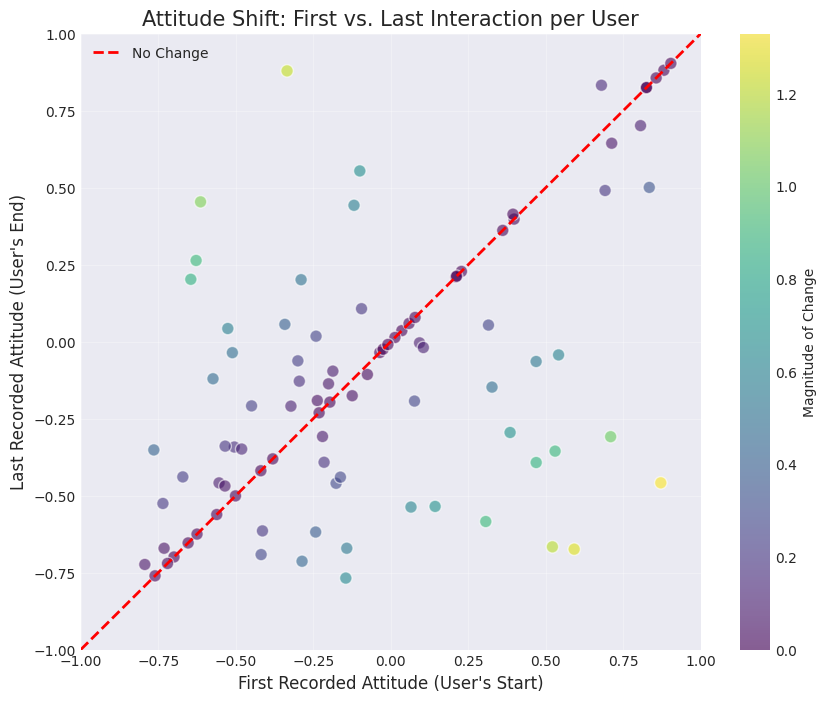

In [20]:
# 1. Sort the data by user and day
# This ensures that each user's records are ordered chronologically
df_sorted = df.sort_values(by=['user_id', 'day'])

# 2. Extract the first and last attitude score for each user using groupby
first_attitudes = df_sorted.groupby('user_id').first()['attitude_score']
last_attitudes = df_sorted.groupby('user_id').last()['attitude_score']

# 3. Combine the data into a single dataframe and remove any potential missing values
comparison_df = pd.DataFrame({
    'first_val': first_attitudes,
    'last_val': last_attitudes
}).dropna()

# 4. Extract the arrays for plotting
start_vals = comparison_df['first_val'].values
end_vals = comparison_df['last_val'].values

plt.figure(figsize=(10, 8))

# Scatter plot: Point color is based on the absolute difference between the first and last attitude
plt.scatter(start_vals, end_vals, alpha=0.6,
            c=np.abs(end_vals - start_vals), cmap='viridis', s=80, edgecolors='white')

# Draw the 'No Change' reference line where x = y
plt.plot([-1, 1], [-1, 1], color='red', linestyle='--', linewidth=2, label='No Change')

# Appearance settings and labels
plt.title('Attitude Shift: First vs. Last Interaction per User', fontsize=15)
plt.xlabel("First Recorded Attitude (User's Start)", fontsize=12)
plt.ylabel("Last Recorded Attitude (User's End)", fontsize=12)
plt.colorbar(label='Magnitude of Change')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(-1, 1)
plt.ylim(-1, 1)

# Save and display the plot
# Assuming 'plot_direc' is defined earlier in your script
plt.savefig(plot_direc + 'user_lifetime_attitude_shift.png')
plt.show()

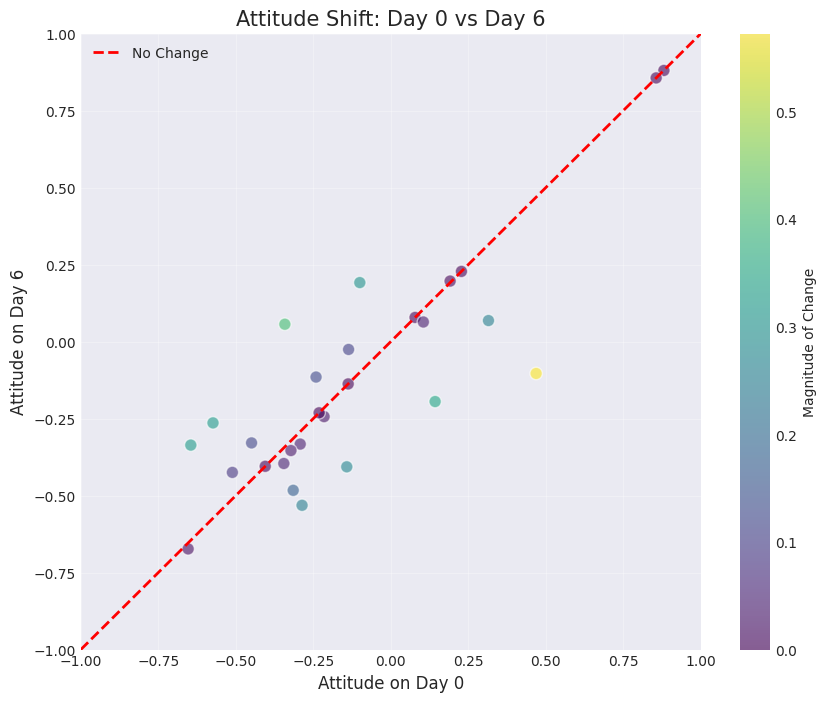

In [21]:
start_day = sorted(propagation_history.keys())[0]
end_day = sorted(propagation_history.keys())[-1]

# Get the sets of user IDs active on the start and end days
users_on_start_day = set(propagation_history[start_day].keys())
users_on_end_day = set(propagation_history[end_day].keys())

# Find the set of users who were active on both the start and end days
common_users_active_both_days = sorted(list(users_on_start_day.intersection(users_on_end_day)))

# Extract attitude values for these common users
start_vals = [propagation_history[start_day][u] for u in common_users_active_both_days]
end_vals = [propagation_history[end_day][u] for u in common_users_active_both_days]

plt.figure(figsize=(10, 8))
plt.scatter(start_vals, end_vals, alpha=0.6, c=np.abs(np.array(end_vals) - np.array(start_vals)), cmap='viridis', s=80, edgecolors='white')

# Add 'No Change' reference line
plt.plot([-1, 1], [-1, 1], color='red', linestyle='--', linewidth=2, label='No Change')

plt.title(f'Attitude Shift: Day {start_day} vs Day {end_day}', fontsize=15)
plt.xlabel(f'Attitude on Day {start_day}', fontsize=12)
plt.ylabel(f'Attitude on Day {end_day}', fontsize=12)
plt.colorbar(label='Magnitude of Change')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(-1, 1)
plt.ylim(-1, 1)

plt.savefig(plot_direc + 'attitude_shift.png')
plt.show()

In [22]:
#pip install diptest


BIMODALITY DETECTION RESULTS
sample_size              : 93
bimodal                  : False
dip_statistic            : 0.023474726650177618
dip_pvalue               : 0.9901712276773327
separation_index         : 0.23809506409158265
bimodality_coefficient   : 0.422228778416144
num_peaks                : 5
variance                 : 0.13499547494587516


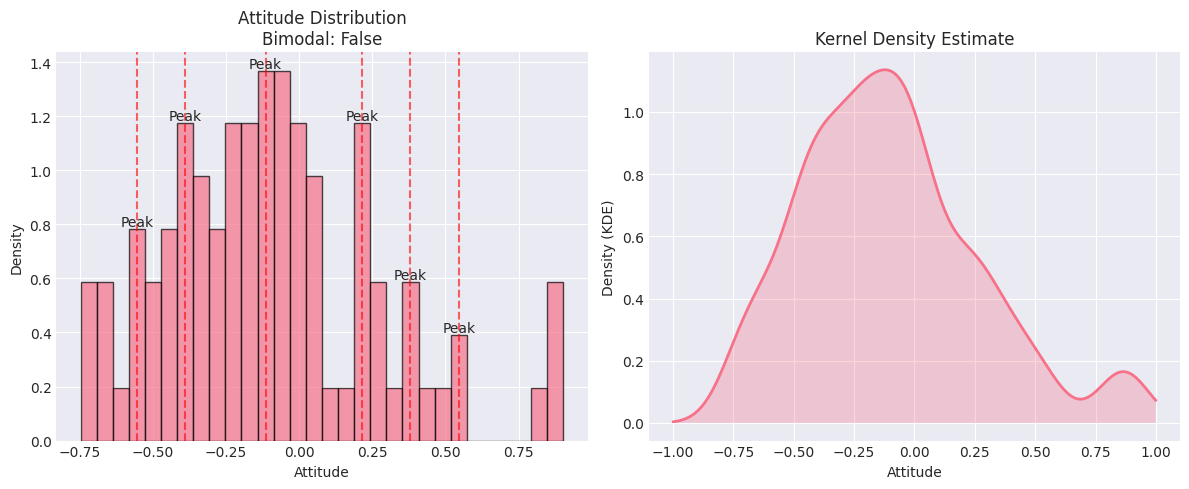

In [23]:
from scipy.stats import entropy as scipy_entropy
from sklearn.neighbors import KernelDensity
import numpy as np # Import numpy

def improved_bimodality_test(attitudes_array, min_sample_size=50):
    """
    Robust bimodality detection using multiple methods.

    Returns:
        dict with multiple metrics
    """
    n = len(attitudes_array)

    if n < min_sample_size:
        return {
            'sample_size': n,
            'bimodal': False,
            'reason': 'insufficient_data',
            'dip_statistic': None,
            'separation_index': None,
            'variance': np.var(attitudes_array)
        }

    # Convert to numpy array for diptest
    attitudes_array_np = np.array(attitudes_array)

    # Method 1: Dip test (most reliable for bounded data)
    try:
        from diptest import diptest
        dip_stat, pval = diptest(attitudes_array_np)
        is_bimodal_dip = pval < 0.05  # Reject unimodality
    except ImportError:
        print("Install diptest: pip install diptest")
        dip_stat, pval, is_bimodal_dip = None, None, None

    # Method 2: Separation index (custom metric)
    # Check if there's a clear gap between two peaks
    hist, bin_edges = np.histogram(attitudes_array_np, bins=20, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Find local maxima
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(hist, height=0.1)

    if len(peaks) >= 2:
        # Find valley between two highest peaks
        top_peaks = sorted(peaks, key=lambda p: hist[p], reverse=True)[:2]
        left_peak, right_peak = sorted(top_peaks)

        valley_region = hist[left_peak:right_peak+1]
        valley_depth = (hist[left_peak] + hist[right_peak]) / 2 - np.min(valley_region)
        peak_height = (hist[left_peak] + hist[right_peak]) / 2

        separation_index = valley_depth / (peak_height + 1e-6)
        is_bimodal_separation = separation_index > 0.3
    else:
        separation_index = 0
        is_bimodal_separation = False

    # Method 3: Variance-based (original BC, used cautiously)
    sk = skew(attitudes_array_np)
    kurt = kurtosis(attitudes_array_np)
    bc = (sk**2 + 1) / (kurt + 3 * (n-1)**2 / ((n-2) * (n-3))) if n > 3 else 0
    is_bimodal_bc = bc > 0.555

    # Consensus decision
    votes = sum([
        is_bimodal_dip if is_bimodal_dip is not None else False,
        is_bimodal_separation,
        is_bimodal_bc
    ])

    return {
        'sample_size': n,
        'bimodal': votes >= 2,  # Majority vote
        'dip_statistic': dip_stat,
        'dip_pvalue': pval,
        'separation_index': separation_index,
        'bimodality_coefficient': bc,
        'num_peaks': len(peaks),
        'variance': np.var(attitudes_array_np)
    }


# Test on propagated attitudes
final_attitudes = list(propagation_history[max(propagation_history.keys())].values())
bimodality_result = improved_bimodality_test(final_attitudes)

print("\n" + "="*60)
print("BIMODALITY DETECTION RESULTS")
print("="*60)
for key, value in bimodality_result.items():
    print(f"{key:25s}: {value}")
print("="*60)

# Visualize with clear peaks marked
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
hist, bin_edges, _ = plt.hist(final_attitudes, bins=30, edgecolor='black', alpha=0.7, density=True)
plt.xlabel('Attitude')
plt.ylabel('Density')
plt.title(f"Attitude Distribution\nBimodal: {bimodality_result['bimodal']}")

# Mark peaks if found
from scipy.signal import find_peaks
peaks, _ = find_peaks(hist, height=0.05)
for peak in peaks:
    peak_x = (bin_edges[peak] + bin_edges[peak+1]) / 2
    plt.axvline(peak_x, color='red', linestyle='--', alpha=0.6)
    plt.text(peak_x, hist[peak], 'Peak', ha='center', va='bottom')

plt.subplot(1, 2, 2)
# KDE plot for smoothed visualization
kde = KernelDensity(bandwidth=0.1, kernel='gaussian')
kde.fit(np.array(final_attitudes).reshape(-1, 1))
x_range = np.linspace(-1, 1, 200).reshape(-1, 1)
log_density = kde.score_samples(x_range)
plt.plot(x_range, np.exp(log_density), linewidth=2)
plt.fill_between(x_range.flatten(), np.exp(log_density), alpha=0.3)
plt.xlabel('Attitude')
plt.ylabel('Density (KDE)')
plt.title('Kernel Density Estimate')

plt.tight_layout()
plt.savefig(plot_direc + 'bimodality_detection_improved.png', dpi=150)
plt.show()

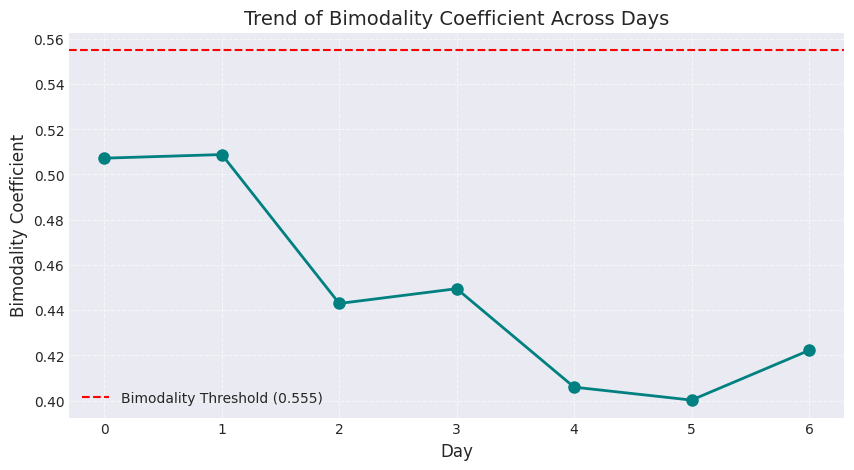

Bimodality values per day: {np.int64(0): np.float64(0.5072), np.int64(1): np.float64(0.5088), np.int64(2): np.float64(0.443), np.int64(3): np.float64(0.4495), np.int64(4): np.float64(0.406), np.int64(5): np.float64(0.4003), np.int64(6): np.float64(0.4222)}


In [24]:

def calculate_bimodality(attitudes_dict):
    """Calculate bimodality coefficient for a dictionary of user attitudes"""
    vals = np.array(list(attitudes_dict.values()))
    n = len(vals)
    if n <= 3:
        return 0

    sk = skew(vals)
    kurt = kurtosis(vals)
    # Bimodality Coefficient formula
    bc = (sk**2 + 1) / (kurt + 3 * (n-1)**2 / ((n-2) * (n-3)))
    return bc

# Extract bimodality trend from propagation history
days = sorted(propagation_history.keys())
bimodality_trend = [calculate_bimodality(propagation_history[day]) for day in days]

# Create the line plot
plt.figure(figsize=(10, 5))
plt.plot(days, bimodality_trend, marker='o', linestyle='-', color='teal', linewidth=2, markersize=8)

plt.title('Trend of Bimodality Coefficient Across Days', fontsize=14)
plt.xlabel('Day', fontsize=12)
plt.ylabel('Bimodality Coefficient', fontsize=12)
plt.xticks(days)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(y=0.555, color='red', linestyle='--', label='Bimodality Threshold (0.555)')
plt.legend()

plt.savefig(plot_direc + 'bimodality_trend.png')
plt.show()

print(f"Bimodality values per day: {dict(zip(days, [round(b, 4) for b in bimodality_trend]))}")


Generating Network Snapshots (Temporal Progression)...


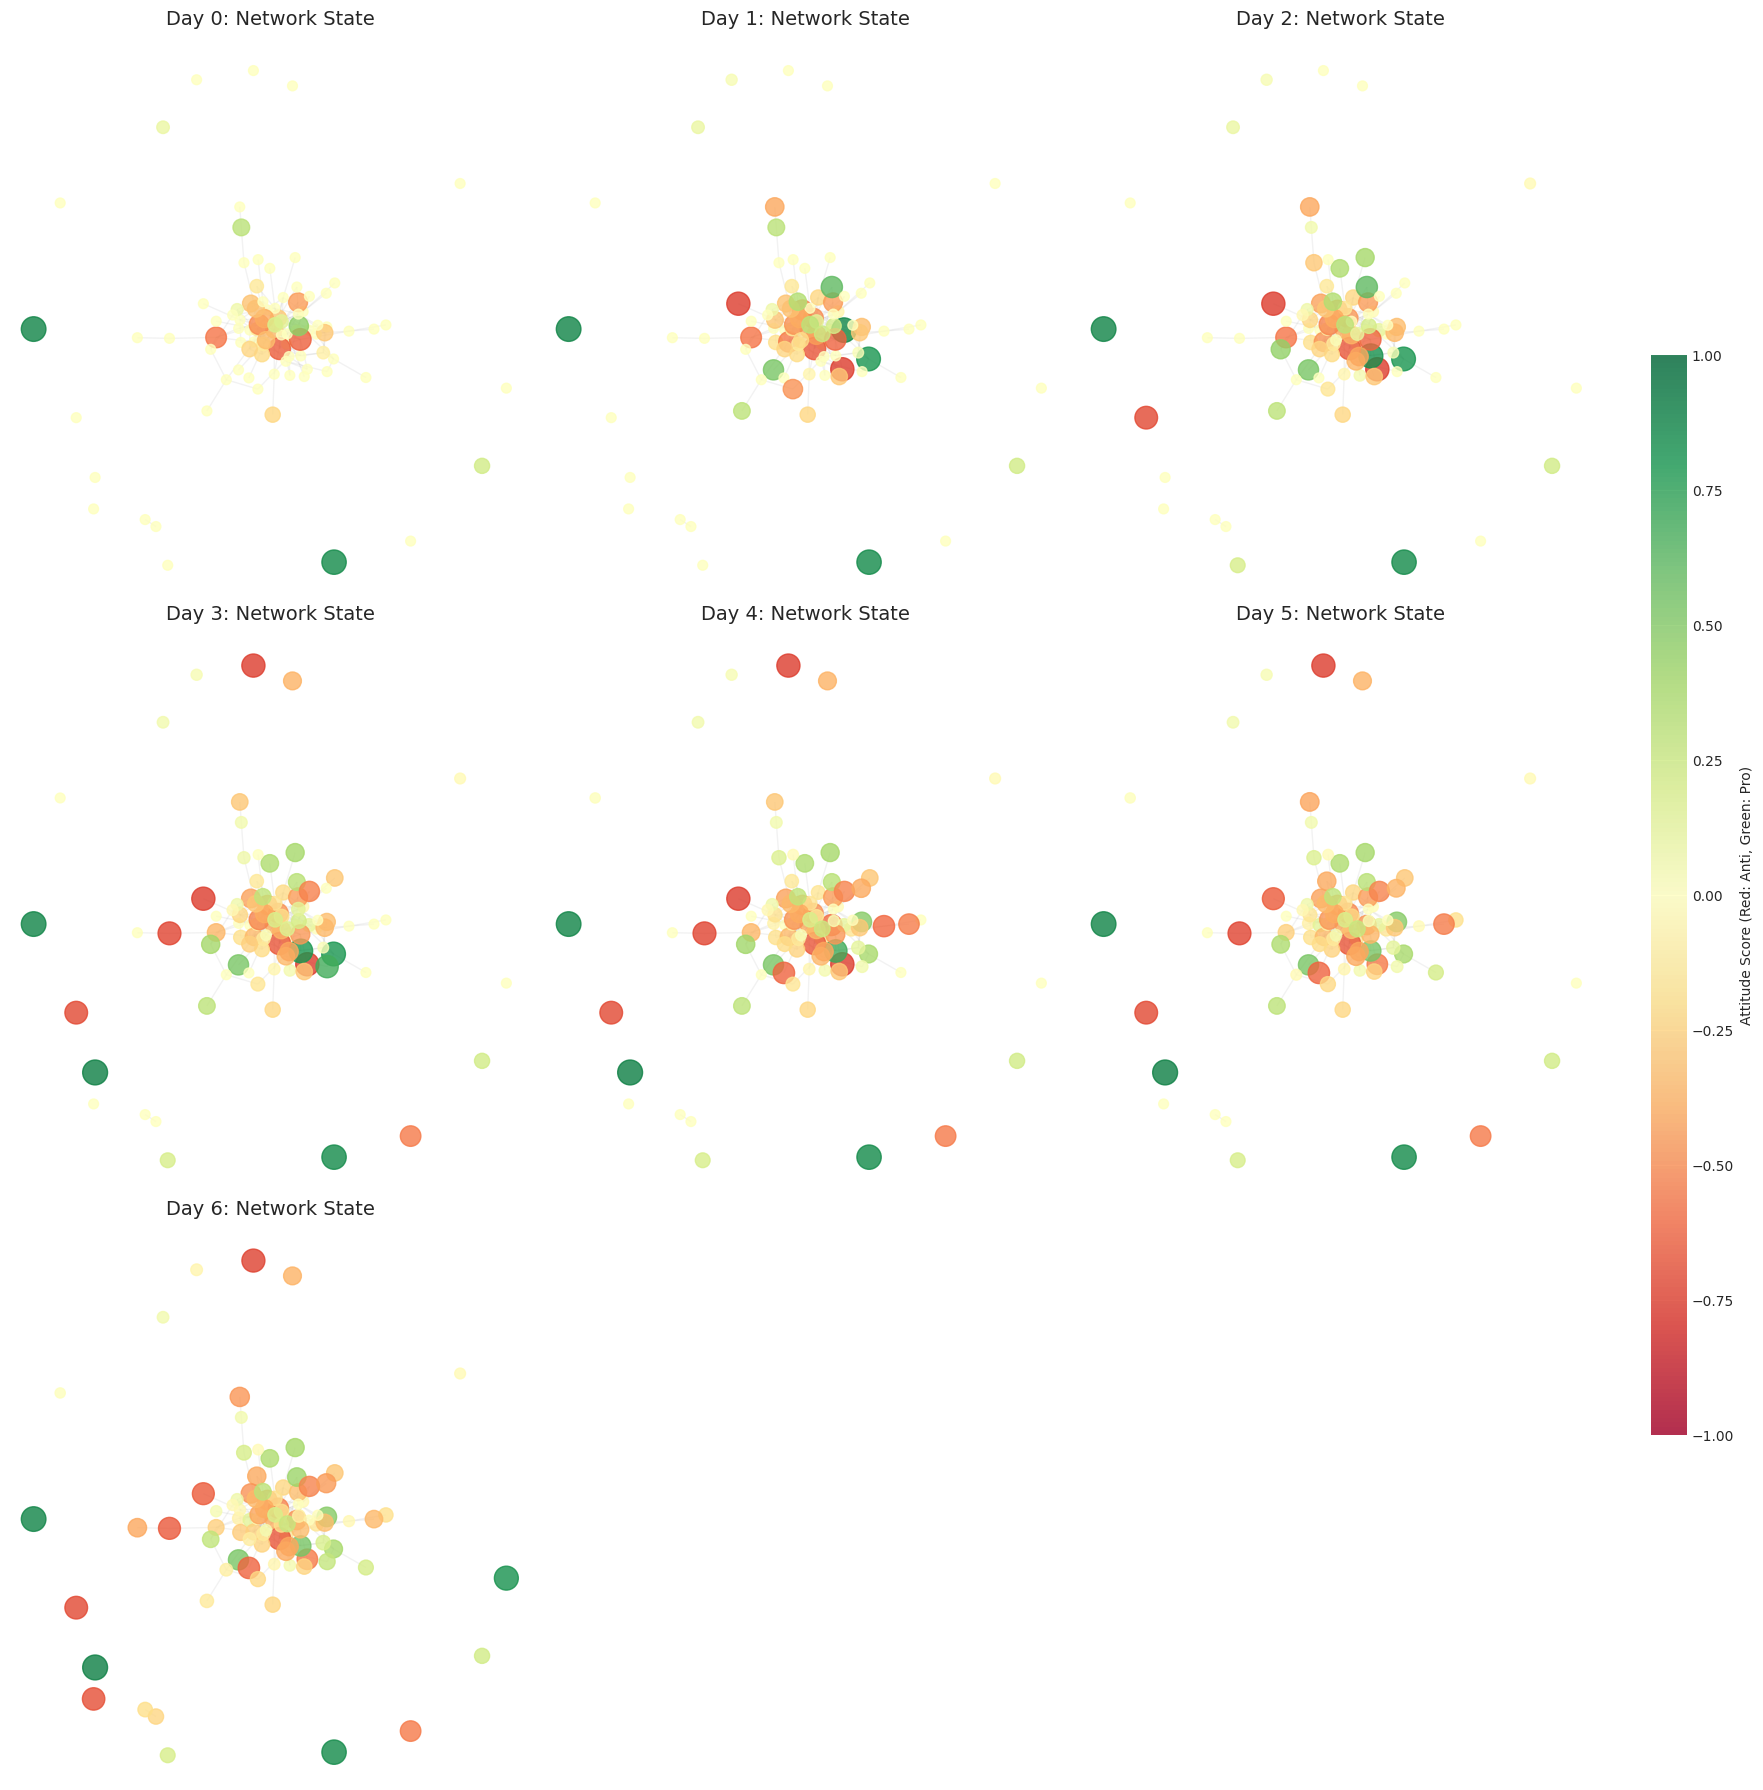

In [25]:
# =================================================================
# Social Network Evolution: Daily Snapshots
# =================================================================
print("\nGenerating Network Snapshots (Temporal Progression)...")

# Identify the available days from our propagation history
days_to_plot = sorted(propagation_history.keys())
num_days = len(days_to_plot)

# Set up the visualization grid (e.g., 2 rows, 3 columns for 5 days)
cols = 3
rows = (num_days + cols - 1) // cols
fig_network_evolution = plt.figure(figsize=(18, rows * 6)) # Assign figure to a variable

# Use a fixed spring layout so nodes stay in the same position across plots
pos = nx.spring_layout(G_undirected, k=0.15, seed=42)

for i, day in enumerate(days_to_plot):
    plt.subplot(rows, cols, i + 1)

    attitudes_dict = propagation_history[day]

    # Map colors from -1 (Red) to 1 (Green)
    node_colors = [attitudes_dict.get(n, 0) for n in G_undirected.nodes()]

    # Scale node size based on attitude intensity (absolute value)
    node_sizes = [(abs(attitudes_dict.get(n, 0)) * 300) + 50 for n in G_undirected.nodes()]

    # Draw nodes
    nodes = nx.draw_networkx_nodes(
        G_undirected,
        pos,
        node_color=node_colors,
        node_size=node_sizes,
        cmap='RdYlGn',
        vmin=-1,
        vmax=1,
        alpha=0.8
    )

    # Draw edges with low opacity
    nx.draw_networkx_edges(G_undirected, pos, alpha=0.1, edge_color='gray')

    plt.title(f"Day {day}: Network State", fontsize=14, pad=15)
    plt.axis('off')

# Add a global colorbar for reference
cbar_ax = fig_network_evolution.add_axes([0.92, 0.2, 0.02, 0.6]) # Use fig_network_evolution
plt.colorbar(nodes, cax=cbar_ax, label='Attitude Score (Red: Anti, Green: Pro)')

plt.tight_layout(rect=[0, 0, 0.9, 1])
fig_network_evolution.savefig(plot_direc + 'network_evolution.png') # Save the figure
plt.show()

## Step 12: Polarization Measurement

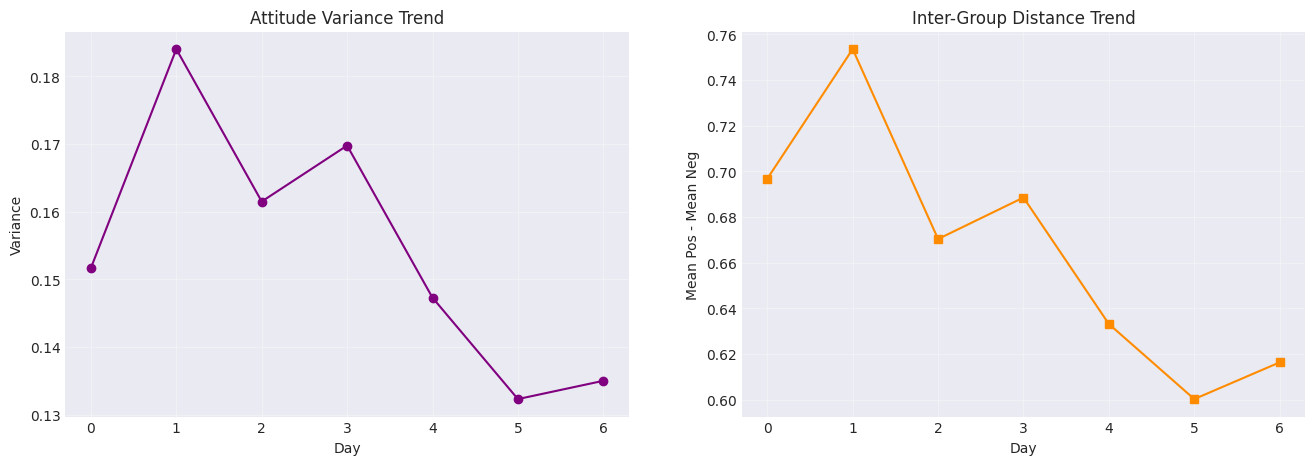

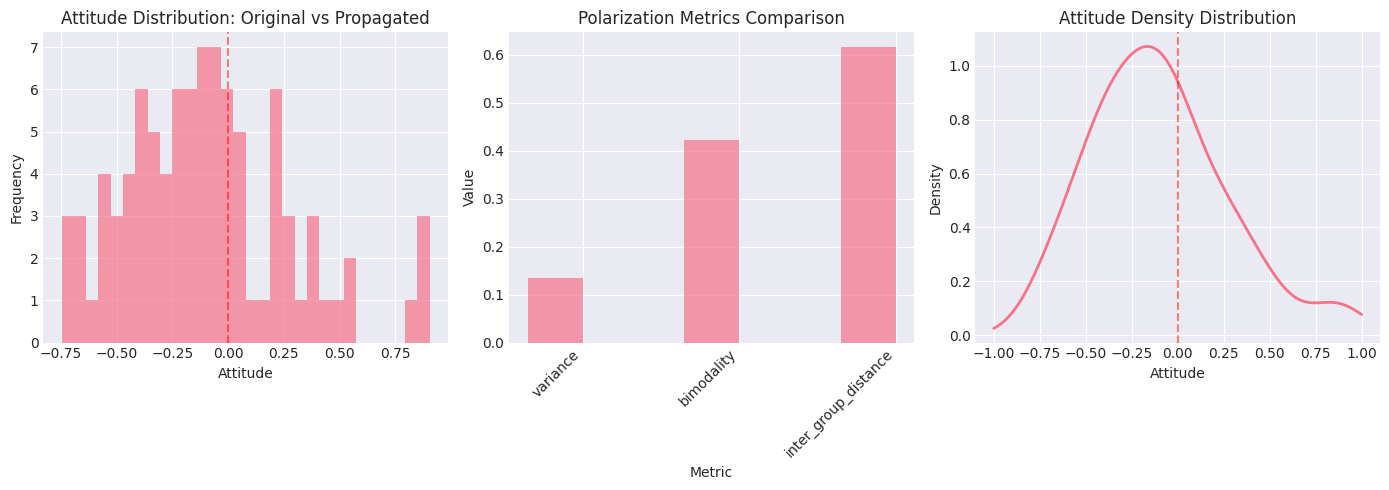

In [26]:
def measure_polarization(attitudes):
    """Measure polarization metrics for a given attitude dictionary"""
    attitudes_array = np.array(list(attitudes.values()))
    n = len(attitudes_array)
    if n == 0: return {'variance': 0, 'bimodality': 0, 'inter_group_distance': 0}

    variance = np.var(attitudes_array)

    from scipy.stats import skew, kurtosis
    sk = skew(attitudes_array)
    kurt = kurtosis(attitudes_array)
    bimodality = (sk**2 + 1) / (kurt + 3 * (n-1)**2 / ((n-2) * (n-3))) if n > 3 else 0

    pos = attitudes_array[attitudes_array > 0]
    neg = attitudes_array[attitudes_array < 0]
    inter_group_distance = np.mean(pos) - np.mean(neg) if len(pos) > 0 and len(neg) > 0 else 0

    return {
        'variance': variance,
        'bimodality': bimodality,
        'inter_group_distance': inter_group_distance
    }

# Calculate daily metrics for trend plots
days = sorted(propagation_history.keys())
daily_pol = {d: measure_polarization(propagation_history[d]) for d in days}

# Calculate specific original and propagated metrics for comparison plots
polarization_original = measure_polarization(dict(zip(user_attitudes['user_id'], user_attitudes['mean_attitude'])))
polarization_propagated = measure_polarization(propagation_history[max(days)])

# Visualization: Trends
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
ax1.plot(days, [daily_pol[d]['variance'] for d in days], marker='o', color='purple', label='Variance')
ax1.set_title('Attitude Variance Trend')
ax1.set_xlabel('Day')
ax1.set_ylabel('Variance')
ax1.grid(True, alpha=0.3)

ax2.plot(days, [daily_pol[d]['inter_group_distance'] for d in days], marker='s', color='darkorange', label='Distance')
ax2.set_title('Inter-Group Distance Trend')
ax2.set_xlabel('Day')
ax2.set_ylabel('Mean Pos - Mean Neg')
ax2.grid(True, alpha=0.3)
plt.savefig(plot_direc + 'polarization_trends.png')
plt.show()

# Visualize polarization comparison
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.hist([user_attitudes['mean_attitude']],
         bins=30, alpha=0.7)
plt.xlabel('Attitude')
plt.ylabel('Frequency')
plt.title('Attitude Distribution: Original vs Propagated')
plt.legend()
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.subplot(1, 3, 2)
metrics = ['variance', 'bimodality', 'inter_group_distance']
original_vals = [polarization_original[m] for m in metrics]
propagated_vals = [polarization_propagated[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, original_vals, width, alpha=0.7)
plt.xlabel('Metric')
plt.ylabel('Value')
plt.title('Polarization Metrics Comparison')
plt.xticks(x, metrics, rotation=45, ha='right')
plt.legend()

plt.subplot(1, 3, 3)
# Kernel density estimation
from scipy.stats import gaussian_kde
kde_original = gaussian_kde(user_attitudes['mean_attitude'].dropna())
kde_propagated = gaussian_kde(user_attitudes['propagated_attitude'].dropna())
x_range = np.linspace(-1, 1, 200)
plt.plot(x_range, kde_original(x_range), linewidth=2)
plt.xlabel('Attitude')
plt.ylabel('Density')
plt.title('Attitude Density Distribution')
plt.legend()
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(plot_direc + 'polarization_comparison.png')
plt.show()

## Step 13: Homophily Measurement

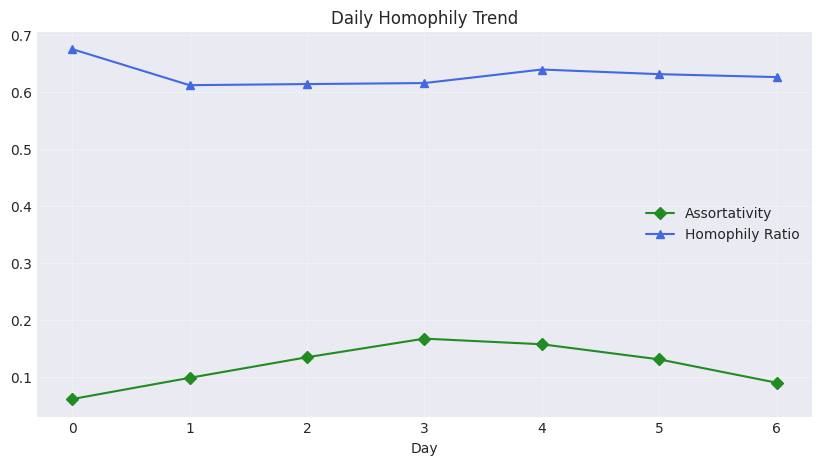

In [27]:
def measure_homophily(G, attitudes):
    """Measure network homophily based on attitudes"""
    if G.number_of_edges() == 0: return {'assortativity': 0, 'homophily_ratio': 0}
    valid_attitudes = {n: attitudes[n] for n in G.nodes() if n in attitudes}
    nx.set_node_attributes(G, valid_attitudes, 'attitude')

    try:
        assortativity = nx.numeric_assortativity_coefficient(G, 'attitude')
    except: assortativity = 0

    similar, total = 0, 0
    for u, v in G.edges():
        if u in valid_attitudes and v in valid_attitudes:
            if valid_attitudes[u] * valid_attitudes[v] > 0: similar += 1
            total += 1
    return {'assortativity': assortativity, 'homophily_ratio': similar/total if total > 0 else 0}

daily_homo = {d: measure_homophily(G_undirected, propagation_history[d]) for d in days}

plt.figure(figsize=(10, 5))
plt.plot(days, [daily_homo[d]['assortativity'] for d in days], marker='D', color='forestgreen', label='Assortativity')
plt.plot(days, [daily_homo[d]['homophily_ratio'] for d in days], marker='^', color='royalblue', label='Homophily Ratio')
plt.title('Daily Homophily Trend')
plt.xlabel('Day')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(plot_direc + 'homophily_trend.png')
plt.show()

## Step 14: Exposure Diversity Analysis


Exposure Diversity Statistics:
count    9.300000e+01
mean     2.332852e-01
std      2.249950e-01
min      0.000000e+00
25%      1.201293e-09
50%      1.850887e-01
75%      4.405921e-01
max      6.744864e-01
Name: exposure_diversity, dtype: float64


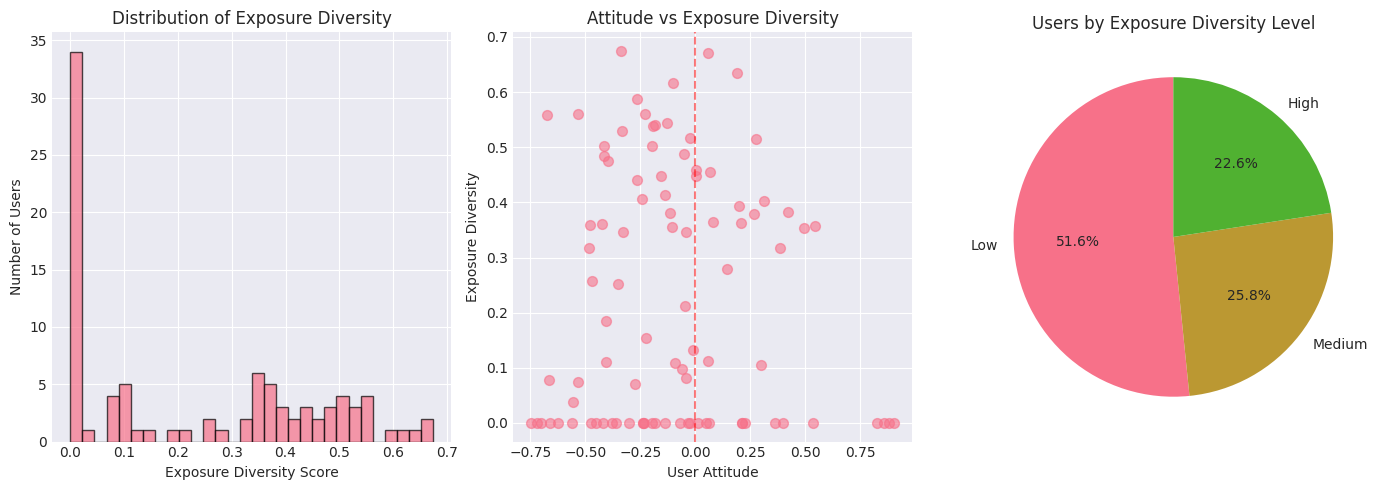


Low diversity (potential echo chamber): 51 users
High diversity (exposed to varied opinions): 4 users


In [28]:
def calculate_exposure_diversity(G, attitudes):
    """
    Calculate exposure diversity for each user

    Returns dictionary with diversity scores for each user
    """
    diversity_scores = {}

    for node in G.nodes():
        neighbors = list(G.neighbors(node))

        if len(neighbors) == 0:
            diversity_scores[node] = 0
            continue

        # Get neighbor attitudes
        neighbor_attitudes = [attitudes[n] for n in neighbors if n in attitudes]

        if len(neighbor_attitudes) == 0:
            diversity_scores[node] = 0
            continue

        # Calculate diversity metrics
        # 1. Standard deviation of neighbor attitudes
        std_diversity = np.std(neighbor_attitudes)

        # 2. Entropy-based diversity (discretize attitudes into bins)
        bins = np.array([-1, -0.5, 0, 0.5, 1])
        hist, _ = np.histogram(neighbor_attitudes, bins=bins)
        probs = hist / hist.sum() if hist.sum() > 0 else hist
        entropy_diversity = entropy(probs + 1e-10)  # Add small value to avoid log(0)

        # 3. Range (max - min)
        range_diversity = np.max(neighbor_attitudes) - np.min(neighbor_attitudes)

        # Combined diversity score (normalized)
        diversity_scores[node] = (std_diversity + entropy_diversity/2 + range_diversity) / 3

    return diversity_scores

# Calculate exposure diversity
diversity_scores = calculate_exposure_diversity(G_undirected, propagated_attitudes)

# Add to user_attitudes
user_attitudes['exposure_diversity'] = user_attitudes['user_id'].map(diversity_scores)

print("\nExposure Diversity Statistics:")
print(user_attitudes['exposure_diversity'].describe())

# Visualize exposure diversity
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.hist(user_attitudes['exposure_diversity'].dropna(), bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Exposure Diversity Score')
plt.ylabel('Number of Users')
plt.title('Distribution of Exposure Diversity')

plt.subplot(1, 3, 2)
plt.scatter(user_attitudes['propagated_attitude'],
            user_attitudes['exposure_diversity'],
            alpha=0.6, s=50)
plt.xlabel('User Attitude')
plt.ylabel('Exposure Diversity')
plt.title('Attitude vs Exposure Diversity')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.subplot(1, 3, 3)
# Categorize users
user_attitudes['diversity_category'] = pd.cut(user_attitudes['exposure_diversity'],
                                               bins=3,
                                               labels=['Low', 'Medium', 'High'])
diversity_counts = user_attitudes['diversity_category'].value_counts()
plt.pie(diversity_counts, labels=diversity_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Users by Exposure Diversity Level')

plt.tight_layout()
plt.savefig(plot_direc + 'exposure_diversity.png')
plt.show()

print(f"\nLow diversity (potential echo chamber): {(user_attitudes['exposure_diversity'] < 0.3).sum()} users")
print(f"High diversity (exposed to varied opinions): {(user_attitudes['exposure_diversity'] > 0.6).sum()} users")

## Step 15: Community Detection

Detecting communities...
Modularity Score: 0.4404
-> Strong community structure detected!

Number of communities detected: 23

Top 10 Communities by Size:
           size  avg_attitude  attitude_std  avg_diversity
community                                                 
22           15       -0.1218        0.3037         0.3470
9            14       -0.1120        0.3469         0.2729
5            13       -0.2251        0.2837         0.2440
12           10        0.0189        0.3019         0.2862
15           10       -0.1111        0.3173         0.3356
4             9       -0.1962        0.3332         0.2284
20            5       -0.1853        0.2119         0.2452
13            2       -0.2163        0.0279         0.0000
6             1        0.2278           NaN         0.0000
1             1        0.0636           NaN         0.0000


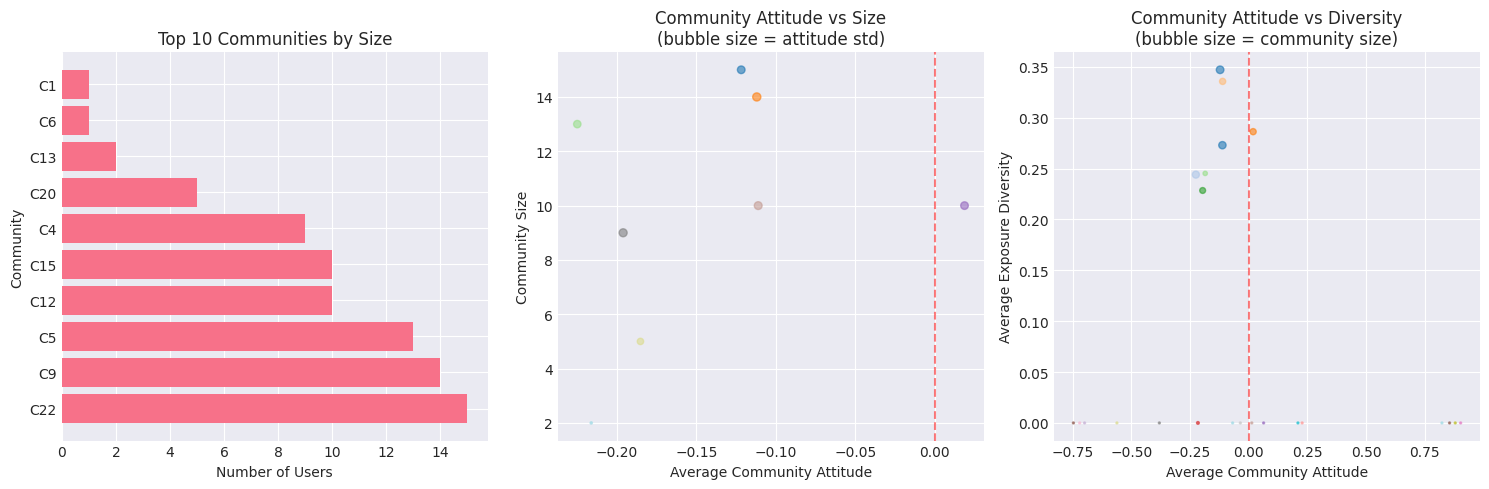

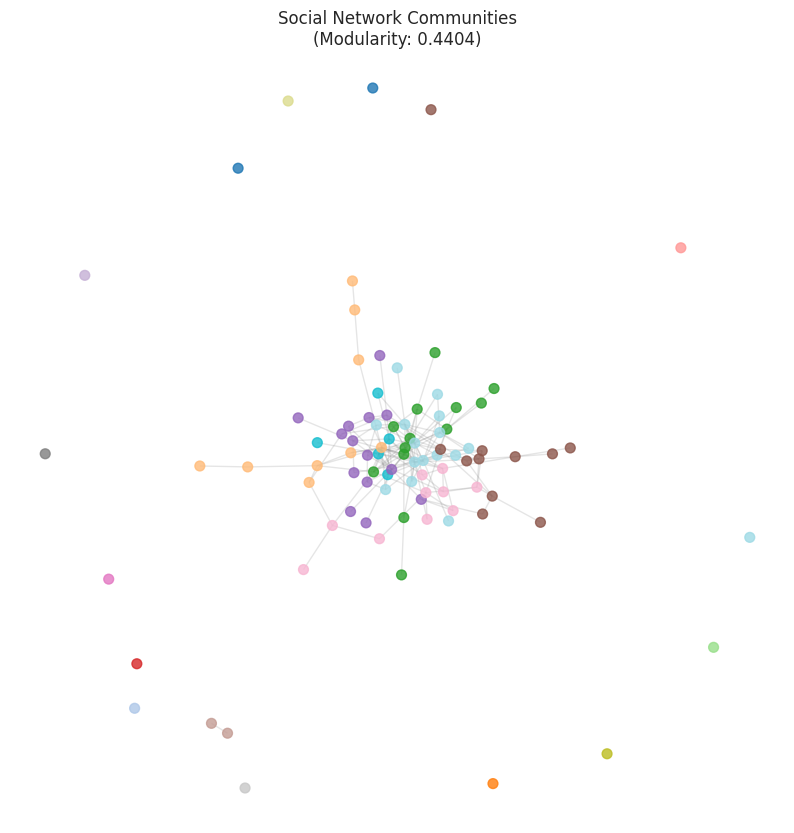

In [29]:
# Community detection using Louvain method
def detect_communities(G):
    """
    Detect communities using Louvain algorithm
    """
    if G.number_of_edges() == 0:
        return {node: 0 for node in G.nodes()}

    # Apply Louvain community detection
    communities = community_louvain.best_partition(G)

    return communities

# Detect communities
print("Detecting communities...")
communities = detect_communities(G_undirected)

# Calculate Modularity Score
modularity_score = community_louvain.modularity(communities, G_undirected)
print(f"Modularity Score: {modularity_score:.4f}")
if modularity_score > 0.3:
    print("-> Strong community structure detected!")
else:
    print("-> Weak community structure (nodes are randomly mixed).")

# Add community labels to users
user_attitudes['community'] = user_attitudes['user_id'].map(communities)

# Analyze communities
num_communities = user_attitudes['community'].nunique()
print(f"\nNumber of communities detected: {num_communities}")

# Calculate community statistics
community_stats = user_attitudes.groupby('community').agg({
    'user_id': 'count',
    'propagated_attitude': ['mean', 'std'],
    'exposure_diversity': 'mean'
}).round(4)

community_stats.columns = ['size', 'avg_attitude', 'attitude_std', 'avg_diversity']
community_stats = community_stats.sort_values('size', ascending=False)

print("\nTop 10 Communities by Size:")
print(community_stats.head(10))

# Visualize communities
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
top_communities = community_stats.head(10)
plt.barh(range(len(top_communities)), top_communities['size'])
plt.yticks(range(len(top_communities)), [f"C{i}" for i in top_communities.index])
plt.xlabel('Number of Users')
plt.ylabel('Community')
plt.title('Top 10 Communities by Size')

plt.subplot(1, 3, 2)
plt.scatter(community_stats['avg_attitude'],
            community_stats['size'],
            s=community_stats['attitude_std']*100,
            alpha=0.6,
            c=range(len(community_stats)),
            cmap='tab20')
plt.xlabel('Average Community Attitude')
plt.ylabel('Community Size')
plt.title('Community Attitude vs Size\n(bubble size = attitude std)')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.subplot(1, 3, 3)
plt.scatter(community_stats['avg_attitude'],
            community_stats['avg_diversity'],
            s=community_stats['size']*2,
            alpha=0.6,
            c=range(len(community_stats)),
            cmap='tab20')
plt.xlabel('Average Community Attitude')
plt.ylabel('Average Exposure Diversity')
plt.title('Community Attitude vs Diversity\n(bubble size = community size)')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(plot_direc + 'community_stats.png')

# Visualize the actual Network Graph
plt.figure(figsize=(10, 10))

# Get positions for the nodes (spring layout looks good for social networks)
pos = nx.spring_layout(G_undirected, k=0.15, seed=42)

# Color nodes based on their community
cmap = plt.cm.get_cmap('tab20', num_communities)
node_colors = [communities[node] for node in G_undirected.nodes()]

# Draw nodes and edges
nx.draw_networkx_nodes(G_undirected, pos, node_size=50,
                       cmap=cmap, node_color=node_colors, alpha=0.8)
nx.draw_networkx_edges(G_undirected, pos, alpha=0.2, edge_color='gray')

plt.title(f"Social Network Communities\n(Modularity: {modularity_score:.4f})")
plt.axis('off')

plt.savefig(plot_direc + 'community_network_graph.png')
plt.show()

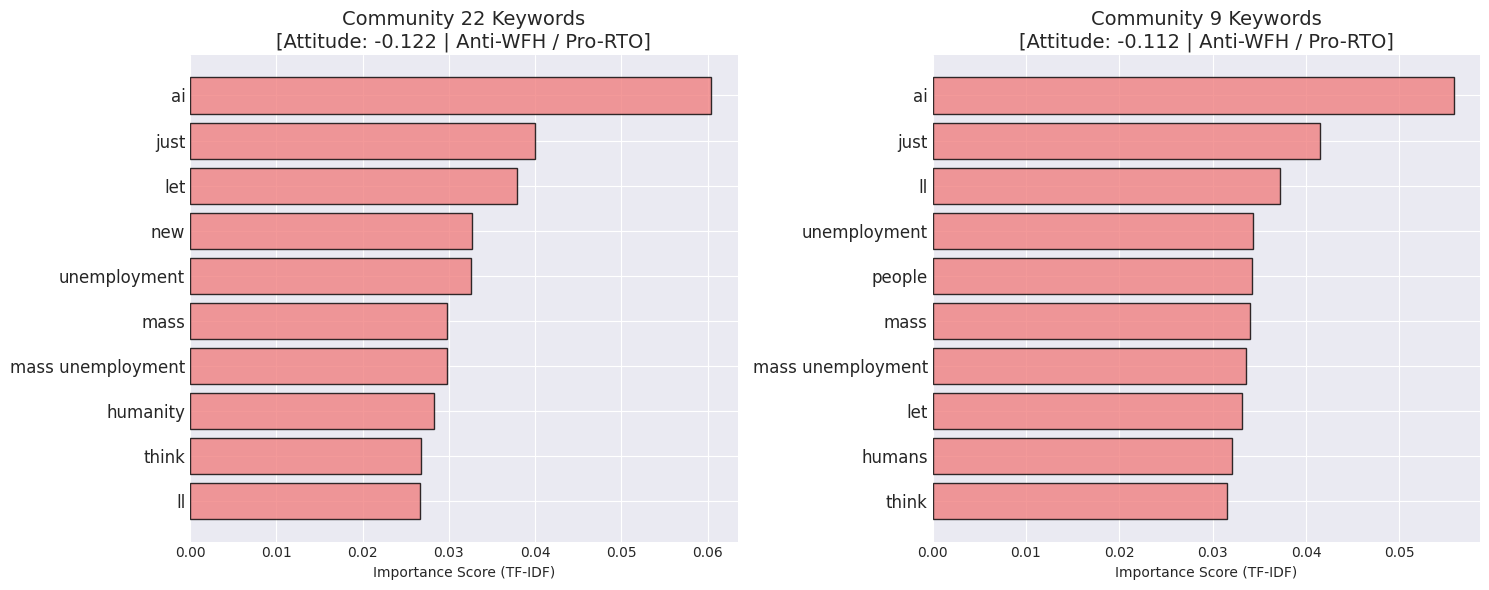

🔥 Top 5 Hashtags per Community:
----------------------------------------

Community 22:
  #ProAI: 11 times
  #HealthcareRevolution: 8 times
  #AIForTheFuture: 7 times
  #AIisnttheAnswer: 5 times
  #HumanValueMatters: 5 times

Community 9:
  #AIRevolution: 10 times
  #JobsAreForTheWeak: 5 times
  #AIForGood: 5 times
  #AIForTheWin: 5 times
  #AI: 4 times


In [30]:

# ۱. اضافه کردن برچسب قبیله به کل دیتافریم اصلی توییت‌ها
# (تا بفهمیم هر توییت توسط عضو کدام قبیله نوشته شده است)
df_with_comm = df.merge(user_attitudes[['user_id', 'community']], on='user_id', how='left')

# ۲. پیدا کردن دو قبیله‌ی پرجمعیت (برای مقایسه دو قطب اصلی)
top_2_communities = community_stats.index[:2].tolist()

plt.figure(figsize=(15, 6))

for i, comm_id in enumerate(top_2_communities):
    # جدا کردن متن توییت‌های این قبیله
    comm_tweets = df_with_comm[df_with_comm['community'] == comm_id]['clean_text'].dropna()

    # ۳. استفاده از TF-IDF برای یافتن کلمات طلایی و متمایز
    # حذف کلمات توقف (مثل the, and, is) و استخراج کلمات تکی و دوتایی (n-grams)
    vectorizer = TfidfVectorizer(stop_words='english', max_features=1000, ngram_range=(1, 2))

    if len(comm_tweets) > 0:
        tfidf_matrix = vectorizer.fit_transform(comm_tweets)

        # محاسبه میانگین اهمیت هر کلمه در این قبیله
        word_scores = np.array(tfidf_matrix.mean(axis=0)).flatten()
        words = np.array(vectorizer.get_feature_names_out())

        # جدا کردن ۱۰ کلمه‌ی برتر
        top_indices = word_scores.argsort()[-10:][::-1]
        top_words = words[top_indices]
        top_scores = word_scores[top_indices]

        # ۴. رسم نمودار میله‌ای
        plt.subplot(1, 2, i+1)

        # تعیین رنگ: اگر میانگین نگرش قبیله مثبت بود (سبز)، اگر منفی بود (قرمز)
        avg_attitude = community_stats.loc[comm_id, 'avg_attitude']
        bar_color = 'mediumseagreen' if avg_attitude > 0 else 'lightcoral'

        plt.barh(range(10)[::-1], top_scores, color=bar_color, edgecolor='black', alpha=0.8)
        plt.yticks(range(10)[::-1], top_words, fontsize=12)

        attitude_label = "Pro-WFH" if avg_attitude > 0 else "Anti-WFH / Pro-RTO"
        plt.title(f"Community {comm_id} Keywords\n[Attitude: {avg_attitude:.3f} | {attitude_label}]", fontsize=14)
        plt.xlabel("Importance Score (TF-IDF)")

plt.tight_layout()
plt.savefig(plot_direc + 'community_keywords_hashtags.png')
plt.show()

# ۵. استخراج داغ‌ترین هشتگ‌های هر قبیله
print("🔥 Top 5 Hashtags per Community:")
print("-" * 40)
for comm_id in top_2_communities:
    comm_tweets = df_with_comm[df_with_comm['community'] == comm_id]['tweet'].dropna().astype(str)
    # پیدا کردن کلماتی که با علامت هشتگ شروع می‌شوند
    hashtags = comm_tweets.str.extractall(r'(#\w+)')[0].value_counts().head(5)

    print(f"\nCommunity {comm_id}:")
    if len(hashtags) > 0:
        for tag, count in hashtags.items():
            print(f"  {tag}: {count} times")
    else:
        print("  No hashtags found in this community.")

## Step 16: Echo Chamber Score Computation


ECHO CHAMBER ANALYSIS RESULTS (Final Day Snapshot)

Overall Echo Chamber Score: 0.517

Component Scores:
  1. Polarization:        0.412
  2. Homophily:          0.358
  3. Low Diversity:      0.767
  4. Community Separation: 0.663

Interpretation: MODERATE - Some echo chamber characteristics present


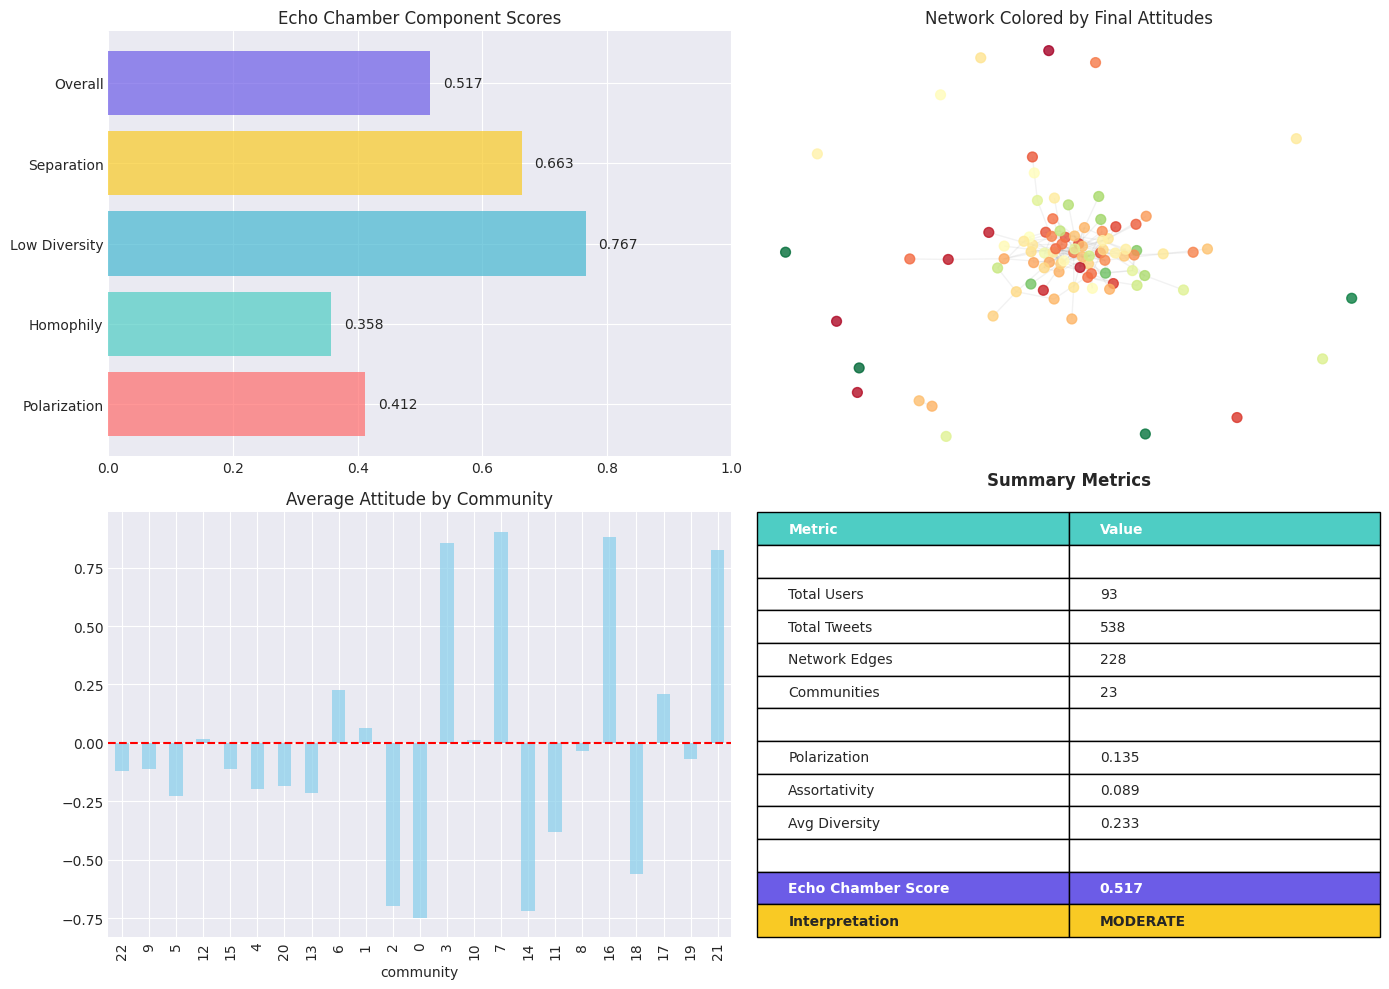

In [31]:
def compute_echo_chamber_score(polarization, homophily, diversity_stats, community_stats):
    """
    Compute comprehensive echo chamber score using current metrics
    """
    # 1. Polarization component (0-1)
    polarization_score = min(1.0, (
        0.4 * min(1.0, polarization['variance'] / 0.5) +
        0.3 * min(1.0, polarization['bimodality'] / 0.7) +
        0.3 * min(1.0, abs(polarization['inter_group_distance']) / 1.5)
    ))

    # 2. Homophily component (0-1)
    homophily_score = min(1.0, (
        0.5 * max(0, homophily['assortativity']) +
        0.5 * homophily['homophily_ratio']
    ))

    # 3. Low diversity component (0-1)
    avg_diversity = diversity_stats.mean()
    diversity_score = max(0, 1 - avg_diversity)

    # 4. Community separation component (0-1)
    between_community_var = community_stats['avg_attitude'].var()
    within_community_var = community_stats['attitude_std'].mean()

    if within_community_var > 0:
        separation_score = min(1.0, between_community_var / (within_community_var + 0.1))
    else:
        separation_score = 0

    # Combine components with weights
    echo_chamber_score = (
        0.3 * polarization_score +
        0.3 * homophily_score +
        0.2 * diversity_score +
        0.2 * separation_score
    )

    return {
        'overall_score': echo_chamber_score,
        'polarization_score': polarization_score,
        'homophily_score': homophily_score,
        'diversity_score': diversity_score,
        'separation_score': separation_score
    }

# Get final day from daily tracking dictionaries
final_day = max(daily_pol.keys())

# Define the missing homophily_propagated variable for the summary table
homophily_propagated = daily_homo[final_day]

# Compute echo chamber score using daily tracking data
echo_chamber_metrics = compute_echo_chamber_score(
    daily_pol[final_day],
    daily_homo[final_day],
    user_attitudes['exposure_diversity'].dropna(),
    community_stats
)

print("\n" + "="*60)
print("ECHO CHAMBER ANALYSIS RESULTS (Final Day Snapshot)")
print("="*60)

print(f"\nOverall Echo Chamber Score: {echo_chamber_metrics['overall_score']:.3f}")
print("\nComponent Scores:")
print(f"  1. Polarization:        {echo_chamber_metrics['polarization_score']:.3f}")
print(f"  2. Homophily:          {echo_chamber_metrics['homophily_score']:.3f}")
print(f"  3. Low Diversity:      {echo_chamber_metrics['diversity_score']:.3f}")
print(f"  4. Community Separation: {echo_chamber_metrics['separation_score']:.3f}")

# Interpretation
overall_score = echo_chamber_metrics['overall_score']
if overall_score < 0.3:
    interpretation = "LOW - Limited echo chamber effects detected"
elif overall_score < 0.6:
    interpretation = "MODERATE - Some echo chamber characteristics present"
else:
    interpretation = "HIGH - Strong echo chamber effects detected"

print(f"\nInterpretation: {interpretation}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Component Scores
ax1 = axes[0, 0]
components = ['Polarization', 'Homophily', 'Low Diversity', 'Separation', 'Overall']
scores = [echo_chamber_metrics['polarization_score'], echo_chamber_metrics['homophily_score'],
          echo_chamber_metrics['diversity_score'], echo_chamber_metrics['separation_score'],
          echo_chamber_metrics['overall_score']]
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#f9ca24', '#6c5ce7']
bars = ax1.barh(components, scores, color=colors, alpha=0.7)
ax1.set_xlim(0, 1)
ax1.set_title('Echo Chamber Component Scores')
for i, bar in enumerate(bars): ax1.text(bar.get_width() + 0.02, i, f'{scores[i]:.3f}', va='center')

# Plot 2: Network Sample (Colored by final day attitudes)
ax2 = axes[0, 1]
pos = nx.spring_layout(G_undirected, k=0.15, seed=42)
node_colors = [propagation_history[final_day].get(n, 0) for n in G_undirected.nodes()]
nx.draw_networkx_nodes(G_undirected, pos, node_size=50, cmap='RdYlGn', node_color=node_colors, alpha=0.8, ax=ax2)
nx.draw_networkx_edges(G_undirected, pos, alpha=0.1, edge_color='gray', ax=ax2)
ax2.set_title('Network Colored by Final Attitudes')
ax2.axis('off')

# Plot 3: Community Averages
ax3 = axes[1, 0]
community_stats['avg_attitude'].plot(kind='bar', ax=ax3, color='skyblue', alpha=0.7)
ax3.set_title('Average Attitude by Community')
ax3.axhline(0, color='red', linestyle='--')

# Plot 4: Summary Table
ax4 = axes[1, 1]
ax4.axis('off')
summary_data = [
    ['Metric', 'Value'],
    ['', ''],
    ['Total Users', f"{len(user_attitudes)}"],
    ['Total Tweets', f"{len(df)}"],
    ['Network Edges', f"{G.number_of_edges()}"],
    ['Communities', f"{num_communities}"],
    ['', ''],
    ['Polarization', f"{polarization_propagated['variance']:.3f}"],
    ['Assortativity', f"{homophily_propagated['assortativity']:.3f}"],
    ['Avg Diversity', f"{user_attitudes['exposure_diversity'].mean():.3f}"],
    ['', ''],
    ['Echo Chamber Score', f"{echo_chamber_metrics['overall_score']:.3f}"],
    ['Interpretation', interpretation.split(' - ')[0]]
]
table = ax4.table(cellText=summary_data, cellLoc='left',
                 bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(2):
    table[(0, i)].set_facecolor('#4ecdc4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style result rows
table[(11, 0)].set_facecolor('#6c5ce7')
table[(11, 1)].set_facecolor('#6c5ce7')
table[(11, 0)].set_text_props(weight='bold', color='white')
table[(11, 1)].set_text_props(weight='bold', color='white')

table[(12, 0)].set_facecolor('#f9ca24')
table[(12, 1)].set_facecolor('#f9ca24')
table[(12, 0)].set_text_props(weight='bold')
table[(12, 1)].set_text_props(weight='bold')

ax4.set_title('Summary Metrics', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(plot_direc + 'echo_chamber_analysis.png')
plt.show()


OPTIMIZED ECHO CHAMBER WEIGHTS (Data-Driven)
polarization        : 0.365
homophily           : 0.069
diversity           : 0.218
separation          : 0.348

Explained variance: 45.1%

OLD overall score (arbitrary weights): 0.517
NEW overall score (optimized weights): 0.590


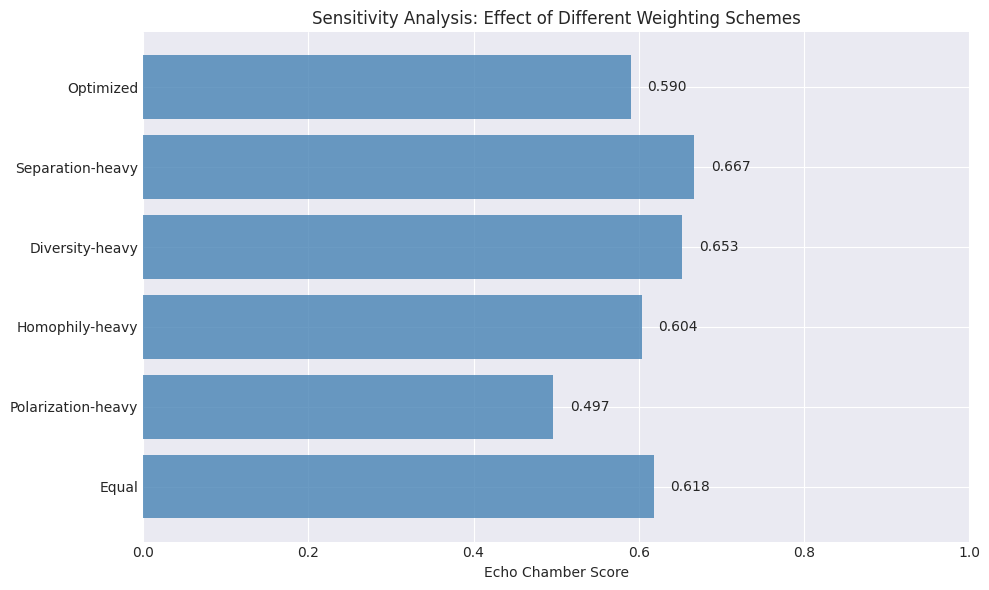


Sensitivity Analysis Results:
               scheme     score
0               Equal  0.617998
1  Polarization-heavy  0.496617
2     Homophily-heavy  0.603551
3     Diversity-heavy  0.652648
4    Separation-heavy  0.667395
5           Optimized  0.590481


In [32]:
"""## Step 16: Echo Chamber Score (WITH WEIGHT JUSTIFICATION)"""

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def optimize_echo_chamber_weights(user_df, community_stats, G_undirected):
    """
    Use PCA to find data-driven weights for echo chamber components.
    """
    # Compute all metrics for each user
    metrics_list = []
    
    for _, user in user_df.iterrows():
        user_id = user['user_id']
        
        # 1. Local polarization (how extreme is this user?)
        local_polarization = abs(user['propagated_attitude'])
        
        # 2. Local homophily (do neighbors share attitude?)
        neighbors = list(G_undirected.neighbors(user_id))
        if len(neighbors) > 0:
            neighbor_attitudes = [user_df[user_df['user_id'] == n]['propagated_attitude'].values[0] 
                                 for n in neighbors if n in user_df['user_id'].values]
            if len(neighbor_attitudes) > 0:
                local_homophily = np.mean([
                    1 if user['propagated_attitude'] * na > 0 else 0 
                    for na in neighbor_attitudes
                ])
            else:
                local_homophily = 0
        else:
            local_homophily = 0
        
        # 3. Diversity (inverted)
        local_diversity = 1 - user['exposure_diversity']
        
        # 4. Community separation (user's distance from opposite camp)
        user_comm = user['community']
        comm_attitude = community_stats.loc[user_comm, 'avg_attitude']
        opposite_attitudes = community_stats[
            community_stats['avg_attitude'] * comm_attitude < 0
        ]['avg_attitude'].values
        
        if len(opposite_attitudes) > 0:
            local_separation = abs(user['propagated_attitude'] - np.mean(opposite_attitudes))
        else:
            local_separation = 0
        
        metrics_list.append({
            'user_id': user_id,
            'polarization': local_polarization,
            'homophily': local_homophily,
            'low_diversity': local_diversity,
            'separation': local_separation
        })
    
    metrics_df = pd.DataFrame(metrics_list)
    
    # Standardize metrics
    scaler = StandardScaler()
    metrics_scaled = scaler.fit_transform(
        metrics_df[['polarization', 'homophily', 'low_diversity', 'separation']]
    )
    
    # PCA to find principal component (captures most variance)
    pca = PCA(n_components=1)
    pca.fit(metrics_scaled)
    
    # PCA loadings = optimal weights
    weights_raw = np.abs(pca.components_[0])  # Absolute values
    weights_normalized = weights_raw / weights_raw.sum()
    
    weight_dict = {
        'polarization': weights_normalized[0],
        'homophily': weights_normalized[1],
        'diversity': weights_normalized[2],
        'separation': weights_normalized[3]
    }
    
    print("\n" + "="*60)
    print("OPTIMIZED ECHO CHAMBER WEIGHTS (Data-Driven)")
    print("="*60)
    for component, weight in weight_dict.items():
        print(f"{component:20s}: {weight:.3f}")
    print(f"\nExplained variance: {pca.explained_variance_ratio_[0]:.1%}")
    print("="*60)
    
    return weight_dict, pca


# Get optimized weights
optimized_weights, pca_model = optimize_echo_chamber_weights(
    user_attitudes, community_stats, G_undirected
)

# Recompute echo chamber score with new weights
final_day = max(daily_pol.keys())

echo_chamber_metrics_optimized = {
    'polarization_score': daily_pol[final_day]['variance'] / 0.5,
    'homophily_score': daily_homo[final_day]['homophily_ratio'],
    'diversity_score': 1 - user_attitudes['exposure_diversity'].mean(),
    'separation_score': community_stats['avg_attitude'].var() / 0.3
}

# Clip to [0, 1]
for key in echo_chamber_metrics_optimized:
    echo_chamber_metrics_optimized[key] = min(1.0, echo_chamber_metrics_optimized[key])

# Apply optimized weights
overall_score_optimized = (
    optimized_weights['polarization'] * echo_chamber_metrics_optimized['polarization_score'] +
    optimized_weights['homophily'] * echo_chamber_metrics_optimized['homophily_score'] +
    optimized_weights['diversity'] * echo_chamber_metrics_optimized['diversity_score'] +
    optimized_weights['separation'] * echo_chamber_metrics_optimized['separation_score']
)

echo_chamber_metrics_optimized['overall_score'] = overall_score_optimized

print(f"\nOLD overall score (arbitrary weights): {echo_chamber_metrics['overall_score']:.3f}")
print(f"NEW overall score (optimized weights): {overall_score_optimized:.3f}")

# Sensitivity analysis: how do weights affect the score?
def sensitivity_analysis(metrics):
    """Test how sensitive the overall score is to weight changes."""
    import itertools
    
    # Test different weight combinations
    weight_sets = {
        'Equal': [0.25, 0.25, 0.25, 0.25],
        'Polarization-heavy': [0.5, 0.2, 0.15, 0.15],
        'Homophily-heavy': [0.2, 0.5, 0.15, 0.15],
        'Diversity-heavy': [0.2, 0.15, 0.5, 0.15],
        'Separation-heavy': [0.2, 0.15, 0.15, 0.5],
        'Optimized': list(optimized_weights.values())
    }
    
    results = []
    for name, weights in weight_sets.items():
        score = (
            weights[0] * metrics['polarization_score'] +
            weights[1] * metrics['homophily_score'] +
            weights[2] * metrics['diversity_score'] +
            weights[3] * metrics['separation_score']
        )
        results.append({'scheme': name, 'score': score})
    
    results_df = pd.DataFrame(results)
    
    plt.figure(figsize=(10, 6))
    plt.barh(results_df['scheme'], results_df['score'], color='steelblue', alpha=0.8)
    plt.xlabel('Echo Chamber Score')
    plt.title('Sensitivity Analysis: Effect of Different Weighting Schemes')
    plt.xlim(0, 1)
    for i, row in results_df.iterrows():
        plt.text(row['score'] + 0.02, i, f"{row['score']:.3f}", va='center')
    plt.tight_layout()
    plt.savefig(plot_direc + 'echo_chamber_sensitivity.png', dpi=150)
    plt.show()
    
    return results_df

sensitivity_results = sensitivity_analysis(echo_chamber_metrics_optimized)
print("\nSensitivity Analysis Results:")
print(sensitivity_results)

In [43]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

def optimize_echo_chamber_weights_2d(user_df, community_stats, G_undirected):
    """
    Use PCA with 2 components to find data-driven weights for echo chamber components,
    capturing both structural and ideological dimensions.
    """
    metrics_list = []
    
    for _, user in user_df.iterrows():
        user_id = user['user_id']
        
        # 1. Local polarization (how extreme is this user's attitude?)
        local_polarization = abs(user['propagated_attitude'])
        
        # 2. Local homophily (do neighbors share the same attitude?)
        neighbors = list(G_undirected.neighbors(user_id))
        if len(neighbors) > 0:
            neighbor_attitudes = [user_df[user_df['user_id'] == n]['propagated_attitude'].values[0] 
                                  for n in neighbors if n in user_df['user_id'].values]
            if len(neighbor_attitudes) > 0:
                local_homophily = np.mean([
                    1 if user['propagated_attitude'] * na > 0 else 0 
                    for na in neighbor_attitudes
                ])
            else:
                local_homophily = 0
        else:
            local_homophily = 0
        
        # 3. Low Diversity (inverted exposure diversity)
        local_diversity = 1 - user['exposure_diversity']
        
        # 4. Community separation (user's distance from the opposite camp)
        user_comm = user['community']
        comm_attitude = community_stats.loc[user_comm, 'avg_attitude']
        opposite_attitudes = community_stats[
            community_stats['avg_attitude'] * comm_attitude < 0
        ]['avg_attitude'].values
        
        if len(opposite_attitudes) > 0:
            local_separation = abs(user['propagated_attitude'] - np.mean(opposite_attitudes))
        else:
            local_separation = 0
        
        metrics_list.append({
            'user_id': user_id,
            'polarization': local_polarization,
            'homophily': local_homophily,
            'diversity': local_diversity, 
            'separation': local_separation
        })
    
    metrics_df = pd.DataFrame(metrics_list)
    
    # Standardize metrics before applying PCA
    scaler = StandardScaler()
    feature_cols = ['polarization', 'homophily', 'diversity', 'separation']
    metrics_scaled = scaler.fit_transform(metrics_df[feature_cols])
    
    # --- Main changes start here ---
    
    # Apply PCA with 2 components
    pca = PCA(n_components=2)
    pca.fit(metrics_scaled)
    
    # Extract and normalize weights for the first principal component (PC1)
    weights_pc1_raw = np.abs(pca.components_[0])
    weights_pc1_norm = weights_pc1_raw / weights_pc1_raw.sum()
    
    # Extract and normalize weights for the second principal component (PC2)
    weights_pc2_raw = np.abs(pca.components_[1])
    weights_pc2_norm = weights_pc2_raw / weights_pc2_raw.sum()
    
    # Get explained variance ratios
    var_ratios = pca.explained_variance_ratio_
    total_var = var_ratios.sum()
    
    print("\n" + "="*60)
    print("OPTIMIZED ECHO CHAMBER WEIGHTS (2-Component PCA)")
    print("="*60)
    print(f"PC1 (Explains {var_ratios[0]:.1%}) - Often the structural dimension:")
    for col, weight in zip(feature_cols, weights_pc1_norm):
        print(f"  {col:20s}: {weight:.3f}")
        
    print(f"\nPC2 (Explains {var_ratios[1]:.1%}) - Often the ideological dimension:")
    for col, weight in zip(feature_cols, weights_pc2_norm):
        print(f"  {col:20s}: {weight:.3f}")
        
    print(f"\nTotal Explained Variance: {total_var:.1%} (Significant improvement)")
    print("="*60)
    
    # Store results in a dictionary
    weight_dicts = {
        'pc1': dict(zip(feature_cols, weights_pc1_norm)),
        'pc2': dict(zip(feature_cols, weights_pc2_norm)),
        'variances': var_ratios
    }
    
    return weight_dicts, pca, metrics_df, metrics_scaled

# ---------------------------------------------------------
# Execution and Final Score Calculation
# ---------------------------------------------------------

weights_2d, pca_model_2d, metrics_df, metrics_scaled = optimize_echo_chamber_weights_2d(
    user_attitudes, community_stats, G_undirected
)

# Assuming echo_chamber_metrics_optimized is already computed and clipped to [0, 1]
# echo_chamber_metrics_optimized = {...}

# 1. Calculate the score based on the first component (PC1)
score_pc1 = (
    weights_2d['pc1']['polarization'] * echo_chamber_metrics_optimized['polarization_score'] +
    weights_2d['pc1']['homophily'] * echo_chamber_metrics_optimized['homophily_score'] +
    weights_2d['pc1']['diversity'] * echo_chamber_metrics_optimized['diversity_score'] +
    weights_2d['pc1']['separation'] * echo_chamber_metrics_optimized['separation_score']
)

# 2. Calculate the score based on the second component (PC2)
score_pc2 = (
    weights_2d['pc2']['polarization'] * echo_chamber_metrics_optimized['polarization_score'] +
    weights_2d['pc2']['homophily'] * echo_chamber_metrics_optimized['homophily_score'] +
    weights_2d['pc2']['diversity'] * echo_chamber_metrics_optimized['diversity_score'] +
    weights_2d['pc2']['separation'] * echo_chamber_metrics_optimized['separation_score']
)

# 3. Combine both scores using their respective explained variances as weights
var1, var2 = weights_2d['variances'][0], weights_2d['variances'][1]
final_combined_score = (var1 * score_pc1 + var2 * score_pc2) / (var1 + var2)

print(f"\nScore from PC1: {score_pc1:.3f}")
print(f"Score from PC2: {score_pc2:.3f}")
print(f"FINAL COMBINED SCORE (2D Optimized): {final_combined_score:.3f}")


OPTIMIZED ECHO CHAMBER WEIGHTS (2-Component PCA)
PC1 (Explains 45.1%) - Often the structural dimension:
  polarization        : 0.365
  homophily           : 0.069
  diversity           : 0.218
  separation          : 0.348

PC2 (Explains 27.9%) - Often the ideological dimension:
  polarization        : 0.079
  homophily           : 0.464
  diversity           : 0.275
  separation          : 0.181

Total Explained Variance: 73.0% (Significant improvement)

Score from PC1: 0.590
Score from PC2: 0.670
FINAL COMBINED SCORE (2D Optimized): 0.621



OPTIMIZED ECHO CHAMBER WEIGHTS (2-Component PCA)
PC1 (Explains 45.1%) - Often the structural dimension:
  polarization        : 0.365
  homophily           : 0.069
  diversity           : 0.218
  separation          : 0.348

PC2 (Explains 27.9%) - Often the ideological dimension:
  polarization        : 0.079
  homophily           : 0.464
  diversity           : 0.275
  separation          : 0.181

Total Explained Variance: 73.0% (Significant improvement)


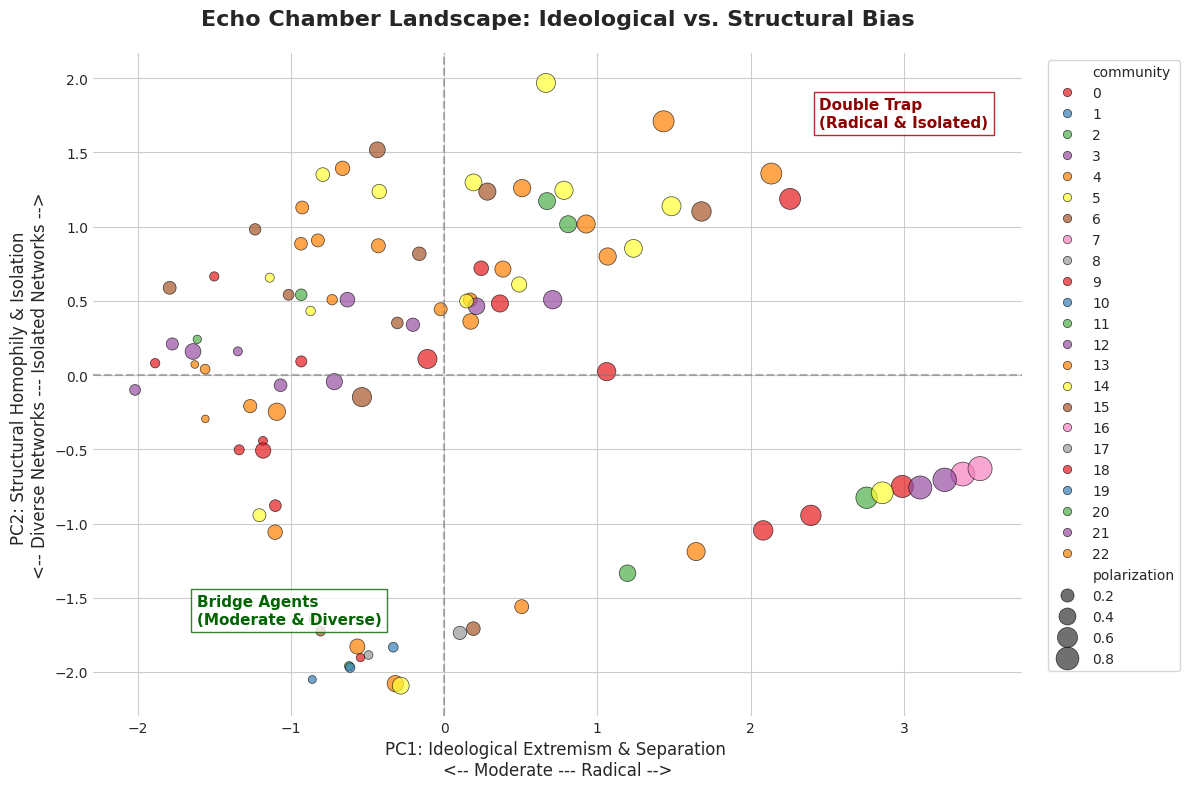

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_echo_chamber_landscape(metrics_df, metrics_scaled, pca_model, user_df):
    """
    Plots the 2D landscape of the echo chamber based on PCA components.
    X-axis: Ideological separation (PC1)
    Y-axis: Structural isolation (PC2)
    """
    # 1. Transform original metrics into the 2D PCA space
    pca_scores = pca_model.transform(metrics_scaled)
    
    # 2. Add PCA coordinates to our dataframe
    plot_df = metrics_df.copy()
    plot_df['PC1_Ideological'] = pca_scores[:, 0]
    plot_df['PC2_Structural']  = pca_scores[:, 1]
    
    # 3. Merge with user_df to get community and attitude data for styling
    plot_df = plot_df.merge(user_df[['user_id', 'community', 'propagated_attitude']], on='user_id')
    
    # 4. Initialize the plot
    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")
    
    # 5. Create scatter plot
    # hue: distinct colors for different communities
    # size: bubble size based on how polarized the user is
    scatter = sns.scatterplot(
        data=plot_df, 
        x='PC1_Ideological', 
        y='PC2_Structural',
        hue='community',
        size='polarization',
        sizes=(30, 300),
        alpha=0.7,
        palette='Set1',
        edgecolor='black'
    )
    
    # 6. Aesthetic configurations
    plt.title('Echo Chamber Landscape: Ideological vs. Structural Bias', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('PC1: Ideological Extremism & Separation \n<-- Moderate --- Radical -->', fontsize=12)
    plt.ylabel('PC2: Structural Homophily & Isolation \n<-- Diverse Networks --- Isolated Networks -->', fontsize=12)
    
    # 7. Draw origin lines to divide into 4 quadrants
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.6)
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.6)
    
    # 8. Add annotations for key quadrants
    x_max, x_min = plot_df['PC1_Ideological'].max(), plot_df['PC1_Ideological'].min()
    y_max, y_min = plot_df['PC2_Structural'].max(), plot_df['PC2_Structural'].min()
    
    # Top-Right: Double Trap (Highly polarized AND highly isolated)
    plt.text(x_max * 0.7, y_max * 0.85, 
             'Double Trap\n(Radical & Isolated)', 
             color='darkred', fontsize=11, fontweight='bold', 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='darkred'))
    
    # Bottom-Left: Bridge Agents (Moderate and diverse exposure)
    plt.text(x_min * 0.8, y_min * 0.8, 
             'Bridge Agents\n(Moderate & Diverse)', 
             color='darkgreen', fontsize=11, fontweight='bold', 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='darkgreen'))
    
    # Move legend outside the plot
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
    plt.tight_layout()
    
    # 9. Save and display
    plt.savefig('echo_chamber_landscape_2d.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return plot_df

# --- نحوه اجرای کد ---
# ابتدا تابع آپدیت‌شده قبلی را اجرا می‌کنیم
weight_dicts, pca_model_2d, metrics_df, metrics_scaled = optimize_echo_chamber_weights_2d(
    user_attitudes, community_stats, G_undirected
)

# سپس نمودار را رسم می‌کنیم
landscape_df = plot_echo_chamber_landscape(
    metrics_df, metrics_scaled, pca_model_2d, user_attitudes
)

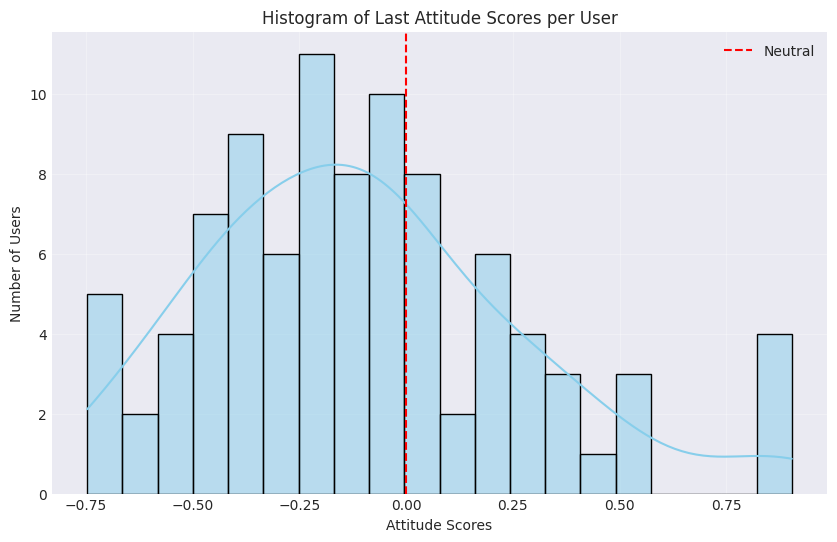

In [34]:
plt.figure(figsize=(10, 6))
sns.histplot(user_attitudes['propagated_attitude'], bins=20, kde=True, color='skyblue', edgecolor='black')
plt.title('Histogram of Last Attitude Scores per User')
plt.xlabel('Attitude Scores')
plt.ylabel('Number of Users')
plt.axvline(x=0, color='red', linestyle='--', label='Neutral')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(plot_direc + 'user_last_attitude_histogram.png')
plt.show()

### Identifying Key Contributors to Low Diversity
We will extract the bottom 10 users by diversity score and examine their local network characteristics.

Top 10 Users Contributing to Low Diversity Metric:


,user_id,mean_attitude,exposure_diversity,community,num_posts,neighbor_avg_attitude,neighbor_count
0,2,-0.746957,0.0,0,3.0,0.0,0.0
2,4,-0.699377,0.0,2,1.0,0.0,0.0
6,8,0.227848,0.0,6,3.0,0.0,0.0
12,15,-0.380697,0.0,11,2.0,0.0,0.0
31,34,0.823567,0.0,21,1.0,0.0,0.0
20,23,0.880275,0.0,16,3.0,0.0,0.0
45,48,0.013164,0.0,10,1.0,0.0,0.0
42,45,0.903272,0.0,7,1.0,0.0,0.0
51,54,-0.720329,0.0,14,1.0,0.0,0.0
43,46,-0.035489,0.0,8,3.0,0.0,0.0



Number of Low-Diversity Users per Community:
community
5     6
9     5
12    4
4     3
13    2
dtype: int64


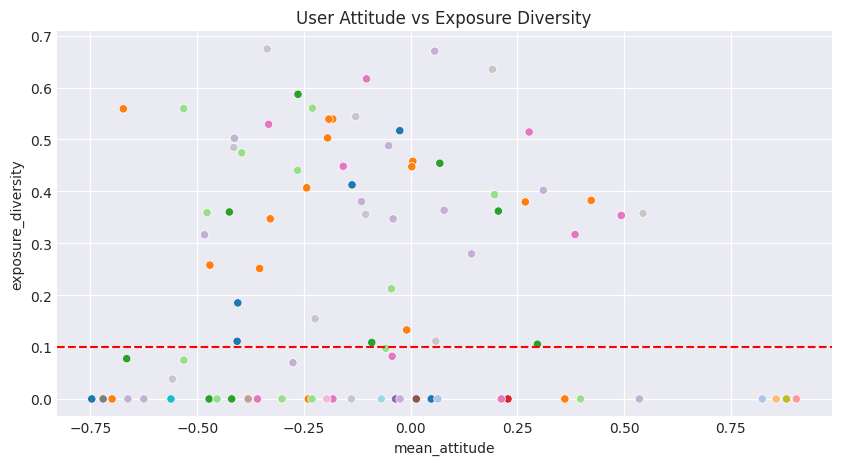

In [36]:
import pandas as pd

# Sort users by exposure diversity to find the lowest
low_diversity_users = user_attitudes.sort_values('exposure_diversity').head(10)[['user_id', 'mean_attitude', 'exposure_diversity', 'community', 'num_posts']]

# For these users, let's see their neighbor's average attitude to confirm the bubble
def get_neighbor_stats(u_id):
    neighbors = list(G_undirected.neighbors(u_id))
    if not neighbors: return 0.0, 0
    neighbor_atts = [propagated_attitudes.get(n, 0) for n in neighbors]
    return np.mean(neighbor_atts), len(neighbors)

low_diversity_users[['neighbor_avg_attitude', 'neighbor_count']] = low_diversity_users['user_id'].apply(lambda x: pd.Series(get_neighbor_stats(x)))

print("Top 10 Users Contributing to Low Diversity Metric:")
display(low_diversity_users)

# Summary by community
low_div_comm_summary = user_attitudes[user_attitudes['exposure_diversity'] < 0.1].groupby('community').size().sort_values(ascending=False)
print("\nNumber of Low-Diversity Users per Community:")
print(low_div_comm_summary.head())

plt.figure(figsize=(10, 5))
sns.scatterplot(data=user_attitudes, x='mean_attitude', y='exposure_diversity', hue='community', palette='tab20', legend=False)
plt.axhline(0.1, color='red', linestyle='--', label='Critical Low Diversity')
plt.title('User Attitude vs Exposure Diversity')
plt.savefig(plot_direc + 'low_diversity_users.png')
plt.show()

### Attitude Variance: Isolated vs. Connected Users
We define 'Isolated' users as those in the bottom 25th percentile of network degree and 'Highly Connected' as those in the top 25th percentile.

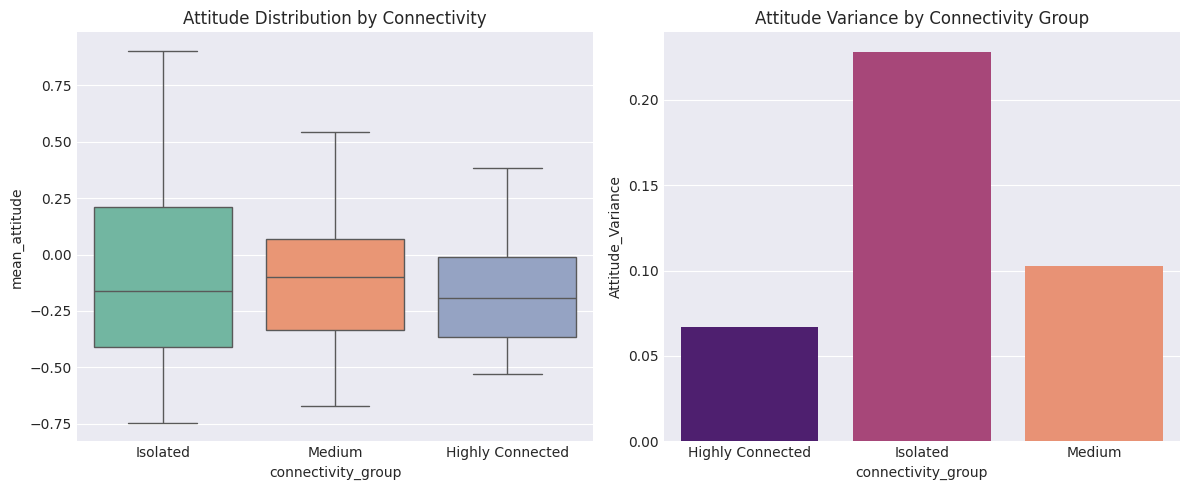

,Count,Avg_Attitude,Attitude_Variance,Avg_Exposure_Diversity
connectivity_group,,,,
Highly Connected,27,-0.1507,0.0672,0.4647
Isolated,34,-0.0654,0.2280,0.0000
Medium,32,-0.1036,0.1024,0.2859


In [37]:
# 1. Calculate degree for each user
degree_dict = dict(G_undirected.degree())
user_attitudes['degree'] = user_attitudes['user_id'].map(degree_dict)

# 2. Define groups based on degree percentiles
q1 = user_attitudes['degree'].quantile(0.25)
q3 = user_attitudes['degree'].quantile(0.75)

user_attitudes['connectivity_group'] = 'Medium'
user_attitudes.loc[user_attitudes['degree'] <= q1, 'connectivity_group'] = 'Isolated'
user_attitudes.loc[user_attitudes['degree'] >= q3, 'connectivity_group'] = 'Highly Connected'

# 3. Compare Variance and Mean Attitude
variance_comparison = user_attitudes.groupby('connectivity_group').agg({
    'user_id': 'count',
    'mean_attitude': ['mean', 'var'],
    'exposure_diversity': 'mean'
}).round(4)

variance_comparison.columns = ['Count', 'Avg_Attitude', 'Attitude_Variance', 'Avg_Exposure_Diversity']

# 4. Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='connectivity_group', y='mean_attitude', data=user_attitudes, palette='Set2')
plt.title('Attitude Distribution by Connectivity')

plt.subplot(1, 2, 2)
sns.barplot(x=variance_comparison.index, y='Attitude_Variance', data=variance_comparison, palette='magma')
plt.title('Attitude Variance by Connectivity Group')

plt.tight_layout()
plt.savefig(plot_direc + 'attitude_variance_by_connectivity.png')
plt.show()

display(variance_comparison)

### Step 17: Recursive Community Detection (Sub-Community Analysis)

To identify if the detected communities contain smaller, more polarized 'micro-echo chambers', we will:
1. Isolate the subgraphs of the largest Louvain communities.
2. Re-run community detection (Louvain) on these subgraphs.
3. Calculate the modularity and count of these sub-communities.

In [38]:
def detect_sub_communities(G, user_df, top_n=5):
    """
    Performs recursive community detection on the top N communities.
    """
    # Get top N communities by size
    top_comm_ids = user_df['community'].value_counts().head(top_n).index.tolist()

    sub_comm_results = []

    for comm_id in top_comm_ids:
        # 1. Get nodes in this community
        comm_nodes = user_df[user_df['community'] == comm_id]['user_id'].tolist()

        # 2. Extract subgraph
        subgraph = G.subgraph(comm_nodes)

        # 3. Detect sub-communities
        if subgraph.number_of_edges() > 0:
            sub_partition = community_louvain.best_partition(subgraph)
            sub_modularity = community_louvain.modularity(sub_partition, subgraph)
            num_sub_comm = len(set(sub_partition.values()))
        else:
            sub_partition = {node: 0 for node in comm_nodes}
            sub_modularity = 0
            num_sub_comm = 1

        # Store results for mapping
        for node, sub_id in sub_partition.items():
            sub_comm_results.append({
                'user_id': node,
                'parent_community': comm_id,
                'sub_community': f"{comm_id}_{sub_id}"
            })

        print(f"Community {comm_id} (Size: {len(comm_nodes)}): Detected {num_sub_comm} sub-communities (Modularity: {sub_modularity:.4f})")

    return pd.DataFrame(sub_comm_results)

# Run recursive detection on top 10 communities
sub_comm_df = detect_sub_communities(G_undirected, user_attitudes, top_n=10)

# Merge back into user_attitudes
if 'sub_community' in user_attitudes.columns:
    user_attitudes = user_attitudes.drop(columns=['parent_community', 'sub_community'])
user_attitudes = user_attitudes.merge(sub_comm_df, on='user_id', how='left')
user_attitudes['sub_community'] = user_attitudes['sub_community'].fillna('None')

# --- COMPUTE ECHO CHAMBER SCORES FOR SUB-COMMUNITIES ---
sub_echo_results = []
unique_subs = [s for s in user_attitudes['sub_community'].unique() if s != 'None']

for sub_id in unique_subs:
    sub_users = user_attitudes[user_attitudes['sub_community'] == sub_id]
    sub_nodes = sub_users['user_id'].tolist()
    sub_G = G_undirected.subgraph(sub_nodes)

    # Prepare metrics for the existing function
    sub_atts = dict(zip(sub_users['user_id'], sub_users['propagated_attitude']))
    pol = measure_polarization(sub_atts)
    homo = measure_homophily(sub_G, sub_atts)
    div_stats = sub_users['exposure_diversity'].dropna()

    # Temporary community stats for the function (treat sub-community as the whole world for the calculation)
    temp_comm_stats = pd.DataFrame([{'avg_attitude': sub_users['propagated_attitude'].mean(), 'attitude_std': sub_users['propagated_attitude'].std()}])

    ecs = compute_echo_chamber_score(pol, homo, div_stats, temp_comm_stats)
    sub_echo_results.append({
        'sub_community': sub_id,
        'size': len(sub_users),
        'echo_chamber_score': ecs['overall_score'],
        'polarization': ecs['polarization_score'],
        'homophily': ecs['homophily_score'],
        'diversity': ecs['diversity_score'],
        'separation': ecs['separation_score']
    })

sub_echo_df = pd.DataFrame(sub_echo_results).sort_values('echo_chamber_score', ascending=False)
print("\nTop Sub-Communities by Echo Chamber Score:")
display(sub_echo_df.head(10))

Community 22 (Size: 15): Detected 3 sub-communities (Modularity: 0.2768)
Community 9 (Size: 14): Detected 3 sub-communities (Modularity: 0.3677)
Community 5 (Size: 13): Detected 4 sub-communities (Modularity: 0.3121)
Community 12 (Size: 10): Detected 3 sub-communities (Modularity: 0.4568)
Community 15 (Size: 10): Detected 3 sub-communities (Modularity: 0.3760)
Community 4 (Size: 9): Detected 2 sub-communities (Modularity: 0.4112)
Community 20 (Size: 5): Detected 1 sub-communities (Modularity: 0.0000)
Community 13 (Size: 2): Detected 1 sub-communities (Modularity: 0.0000)
Community 0 (Size: 1): Detected 1 sub-communities (Modularity: 0.0000)
Community 2 (Size: 1): Detected 1 sub-communities (Modularity: 0.0000)

Top Sub-Communities by Echo Chamber Score:


,sub_community,size,echo_chamber_score,polarization,homophily,diversity,separation
3,4_1,6,0.588608,0.311953,0.454448,0.793440,1.0
6,20_0,5,0.561378,0.156376,0.545001,0.754824,1.0
14,5_2,4,0.557598,0.073177,0.500000,0.928225,1.0
10,13_0,2,0.550093,0.000311,0.500000,1.000000,1.0
12,5_3,4,0.549230,0.316901,0.446205,0.601490,1.0
20,5_1,2,0.542031,0.005968,0.500000,0.951203,1.0
16,12_2,4,0.535654,0.054103,0.500000,0.847117,1.0
21,15_1,3,0.516589,0.001980,0.500000,0.829973,1.0
7,9_1,4,0.510863,0.189787,0.333333,0.769637,1.0
1,12_1,4,0.490380,0.181216,0.333333,0.680078,1.0


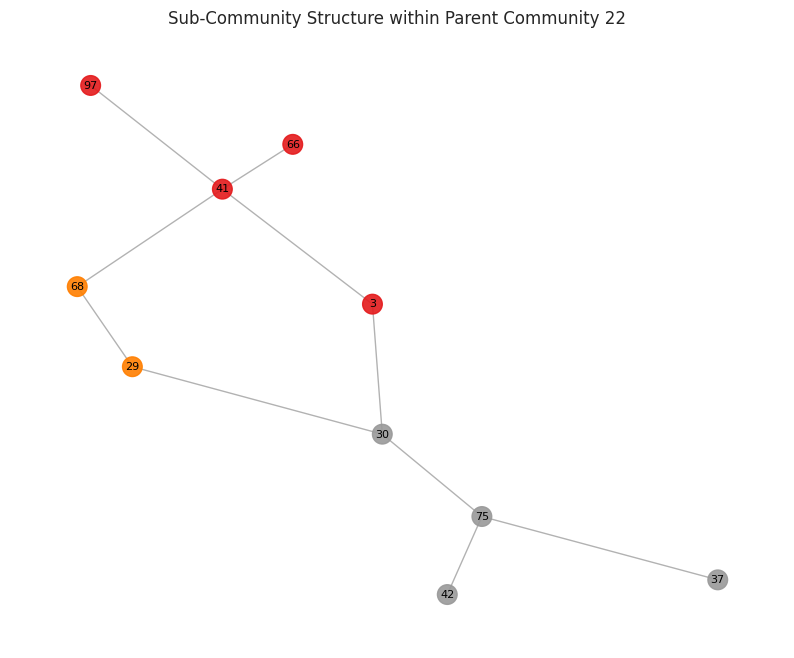

In [39]:
# Visualize sub-communities for the largest community
largest_comm_id = user_attitudes['community'].value_counts().index[0]
largest_comm_nodes = user_attitudes[user_attitudes['community'] == 12]['user_id'].tolist()
sub_G = G_undirected.subgraph(largest_comm_nodes)

plt.figure(figsize=(10, 8))
pos_sub = nx.spring_layout(sub_G, seed=42)

# Color by sub-community
sub_labels = user_attitudes[user_attitudes['user_id'].isin(largest_comm_nodes)]['sub_community']
unique_subs = sub_labels.unique()
cmap_sub = plt.cm.get_cmap('Set1', len(unique_subs))
color_map = {label: i for i, label in enumerate(unique_subs)}
node_colors = [color_map[user_attitudes[user_attitudes['user_id'] == n]['sub_community'].values[0]] for n in sub_G.nodes()]

nx.draw_networkx_nodes(sub_G, pos_sub, node_color=node_colors, cmap=cmap_sub, node_size=200, alpha=0.9)
nx.draw_networkx_edges(sub_G, pos_sub, alpha=0.3)
nx.draw_networkx_labels(sub_G, pos_sub, font_size=8)

plt.title(f"Sub-Community Structure within Parent Community {largest_comm_id}")
plt.axis('off')
plt.show()

In [40]:
import plotly.graph_objects as go
import networkx as nx
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# --- 1. PRE-CALCULATE COMMUNITY KEYWORDS ---
def get_community_keywords(df_tweets, comm_col, top_n=5):
    keywords_map = {}
    unique_comms = df_tweets[comm_col].unique()
    for cid in unique_comms:
        if cid == 'None': continue
        texts = df_tweets[df_tweets[comm_col] == cid]['clean_text'].dropna()
        if len(texts) > 2:
            vectorizer = TfidfVectorizer(stop_words='english', max_features=20)
            tfidf_matrix = vectorizer.fit_transform(texts)
            scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
            words = vectorizer.get_feature_names_out()
            top_words = [words[i] for i in scores.argsort()[-top_n:][::-1]]
            keywords_map[cid] = ", ".join(top_words)
        else:
            keywords_map[cid] = "Insufficient data"
    return keywords_map

# Map keywords for tooltips
parent_keywords = get_community_keywords(df_with_comm, 'community')
sub_keywords = get_community_keywords(user_attitudes.merge(df_with_comm[['user_id', 'clean_text']], on='user_id'), 'sub_community')

# --- 2. PREPARE ECS MAPS ---
# Map Parent Community ECS
parent_ecs_map = {}
for comm_id in user_attitudes['community'].unique():
    sub_users = user_attitudes[user_attitudes['community'] == comm_id]
    sub_G = G_undirected.subgraph(sub_users['user_id'].tolist())
    sub_atts = dict(zip(sub_users['user_id'], sub_users['propagated_attitude']))
    pol = measure_polarization(sub_atts)
    homo = measure_homophily(sub_G, sub_atts)
    temp_stats = pd.DataFrame([{'avg_attitude': sub_users['propagated_attitude'].mean(), 'attitude_std': sub_users['propagated_attitude'].std()}])
    res = compute_echo_chamber_score(pol, homo, sub_users['exposure_diversity'].dropna(), temp_stats)
    parent_ecs_map[comm_id] = res['overall_score']

# Map Sub-Community ECS
sub_ecs_map = dict(zip(sub_echo_df['sub_community'], sub_echo_df['echo_chamber_score']))

def create_interactive_network(df_users, G):
    fig = go.Figure()
    pos = nx.spring_layout(G, k=0.15, seed=42)

    # --- [Trace 0] Add Edges ---
    edge_x, edge_y = [], []
    for edge in G.edges():
        if edge[0] in pos and edge[1] in pos:
            x0, y0 = pos[edge[0]]
            x1, y1 = pos[edge[1]]
            edge_x.extend([x0, x1, None])
            edge_y.extend([y0, y1, None])

    fig.add_trace(go.Scatter(
        x=edge_x, y=edge_y,
        line=dict(width=0.5, color='#888'),
        hoverinfo='none', mode='lines', opacity=0.2, name='Interactions'
    ))

    unique_communities = sorted(df_users['community'].unique())
    num_comms = len(unique_communities)

    # --- TRACE SET 1: GLOBAL VIEW (Parent ECS) ---
    for comm_id in unique_communities:
        comm_data = df_users[df_users['community'] == comm_id].copy()
        comm_ecs = parent_ecs_map.get(comm_id, 0.5)
        p_keys = parent_keywords.get(comm_id, "N/A")

        fig.add_trace(go.Scatter(
            x=[pos[u][0] for u in comm_data['user_id']],
            y=[pos[u][1] for u in comm_data['user_id']],
            mode='markers',
            name=f'Comm {comm_id} (Global)',
            visible=True,
            marker=dict(
                size=12,
                color=[comm_ecs] * len(comm_data),
                colorscale='Reds', cmin=0.2, cmax=0.8,
                showscale=bool(comm_id == unique_communities[0]),
                colorbar=dict(title="Parent ECS", thickness=15, x=1.0) if comm_id == unique_communities[0] else None,
                line=dict(width=1, color='white')
            ),
            text=comm_data.apply(lambda r: (
                f"<b>User {r['user_id']}</b><br>"
                f"Parent ECS: {comm_ecs:.3f}<br>"
                f"Parent Keywords: {p_keys}<br>"
                f"Sub-Comm: {r['sub_community']}<br>"
                f"User Attitude: {r['mean_attitude']:.2f}"
            ), axis=1),
            hoverinfo='text'
        ))

    # --- TRACE SET 2: DRILL-DOWN VIEW (Sub-Comm ECS) ---
    for comm_id in unique_communities:
        comm_data = df_users[df_users['community'] == comm_id].copy()
        sub_colors = [sub_ecs_map.get(s, 0) for s in comm_data['sub_community']]

        fig.add_trace(go.Scatter(
            x=[pos[u][0] for u in comm_data['user_id']],
            y=[pos[u][1] for u in comm_data['user_id']],
            mode='markers',
            name=f'Comm {comm_id} (Drill-down)',
            visible=False,
            marker=dict(
                size=12,
                color=sub_colors,
                colorscale='Viridis', cmin=0.2, cmax=0.8,
                showscale=bool(comm_id == unique_communities[0]),
                colorbar=dict(title="Sub-Comm ECS", thickness=15, x=1.12) if comm_id == unique_communities[0] else None,
                line=dict(width=1, color='#333')
            ),
            text=comm_data.apply(lambda r: (
                f"<b>User {r['user_id']}</b><br>"
                f"Sub-Comm: {r['sub_community']} (ECS: {sub_ecs_map.get(r['sub_community'], 0):.3f})<br>"
                f"Sub-Keywords: {sub_keywords.get(r['sub_community'], 'N/A')}<br>"
                f"User Attitude: {r['mean_attitude']:.2f}"
            ), axis=1),
            hoverinfo='text'
        ))

    global_visibility = [True] + [True] * num_comms + [False] * num_comms
    buttons = [
        dict(label="Global View (Parent ECS)", method="update",
             args=[{"visible": global_visibility},
                   {"title": "Global Network: Node Color = Parent Community Echo Chamber Score"}])
    ]

    for i, comm_id in enumerate(unique_communities):
        step_visibility = [True] + [False] * num_comms + [False] * num_comms
        step_visibility[1 + num_comms + i] = True
        buttons.append(dict(
            label=f"Drill-down Comm {comm_id}",
            method="update",
            args=[{"visible": step_visibility}, {"title": f"Community {comm_id} Micro-Echo Chambers"}]
        ))

    fig.update_layout(
        updatemenus=[dict(active=0, buttons=buttons, x=0.01, y=1.15)],
        template="plotly_white", height=800, showlegend=False,
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
    )
    return fig

fig = create_interactive_network(user_attitudes, G_undirected)
fig.show()